# Parte 3 - Geopolitica y Crudo WTI: Inteligencia en Tiempo Real
## Proyecto de Ciencia de Datos - Portfolio AFI Madrid (septiembre 2026)

---

**Snapshot:** 23 de marzo de 2026
**Contexto:** Guerra activa EEUU-Iran. Estrecho de Ormuz bloqueado.
WTI +44% YTD (~$99/barril). Mayor swing intradiario registrado (-14.4%) provocado
por un post de Trump en Truth Social a las 07:05 ET.

### Estructura del notebook

| Bloque | Titulo | Descripcion |
|--------|--------|-------------|
| **1** | Ingesta Polymarket | Fetch API, 3-layer keyword filter, clasificacion (717 mercados) |
| **2** | Snapshot de mercados | Valores actuales, percentiles historicos, analisis intradiario Trump |
| **3** | Taxonomia y visualizacion | Heatmap, ranking, curvas implicitas, tabla de sintesis |
| **4** | Motor de inferencia cruzada | Perfil vs modelo, inferencias, divergencias, contagio sistemico |
| **5** | Intelligence Brief y Dashboard | Brief ejecutivo, semaforo por escenario, dashboard HTML |

### Fuentes de datos
- **Polymarket API** (`gamma-api.polymarket.com/markets`) - probabilities de mercados de prediccion
- **yfinance** - series historicas WTI, OVX, VIX, DXY, S&P500, Gold, XOM, CVX, BTC, NASDAQ
- **data_clean/** - series historicas limpias (WTI 1986-2026, OVX, GPR, GDELT, VIX, DXY, Brent)
- **context/** - model_summary.json, master_dataset_schema.json (Partes 1 y 2)

### Modelos de referencia (Partes 1 y 2)
- **RandomForest**: AUC=0.615, F1=0.571, recall=0.918, threshold=0.46. Top SHAP: ovx_lag1 (0.0989)
- **RSJD** (Regime-Switching Jump-Diffusion): regimen high_stress drift=+18.4%, vol=50.7%, p_stay=0.977 (~43 dias)
- **Umbrales clave**: OVX>40 (alerta), OVX>46.1 (P80 high_stress), GPR>120 (critico)

---


---
# BLOQUE 1 - Ingesta y Limpieza de Seniales Polymarket

**Objetivo:** Conectar a la API publica de Polymarket, filtrar mercados relevantes para geopolitica
y crudo mediante 3 capas de keywords, limpiar y clasificar cada mercado con columnas operativas
para el motor de inferencia.

**Outputs:** `outputs/data/parte3/polymarket_clean.parquet` (717 mercados, 19 columnas)

**Columnas clave generadas:**
- `conviction_tier`: descontado (>90%) / muy_probable (75-90%) / probable (60-75%) / cola (<60%)
- `signal_quality_score`: 0.35*yes_prob + 0.30*liquidity + 0.20*volume + 0.15*time * relevance_multiplier
- `scenario_horizon`: short_term (0-7d) / medium_term (8-30d) / long_term (>30d)
- `selection_flag_for_inference`: marcador booleano para el motor de inferencia del Bloque 4


In [1]:
import requests
import json
import html
import re
import pandas as pd
import numpy as np
from datetime import datetime, timezone, date
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

ROOT        = Path('.')
DATA_OUT    = ROOT / 'outputs' / 'data'    / 'parte3'
FIGURES_OUT = ROOT / 'outputs' / 'figures' / 'parte3'
DATA_OUT.mkdir(parents=True, exist_ok=True)
FIGURES_OUT.mkdir(parents=True, exist_ok=True)

SNAPSHOT_DATE = date(2026, 3, 23)
print(f"Snapshot date : {SNAPSHOT_DATE}")
print(f"Data out      : {DATA_OUT}")


Snapshot date : 2026-03-23
Data out      : outputs\data\parte3


---
## 1. Fetch de datos — Polymarket API

Llamada paginada a `https://gamma-api.polymarket.com/markets` ordenando por `volume24hr` descendente.  
Se guarda el JSON crudo antes de cualquier transformación.


In [2]:
BASE_URL = "https://gamma-api.polymarket.com/markets"
BATCH    = 200
MAX_ITER = 20

all_markets = []
offset      = 0

print("Iniciando descarga paginada...")
for i in range(MAX_ITER):
    params = {
        "active"    : "true",
        "closed"    : "false",
        "limit"     : BATCH,
        "offset"    : offset,
        "order"     : "volume24hr",
        "ascending" : "false",
    }
    try:
        r = requests.get(BASE_URL, params=params, timeout=20)
        r.raise_for_status()
        batch = r.json()
    except Exception as e:
        print(f"  Error en offset {offset}: {e}")
        break

    if not batch:
        print(f"  Pagina {i+1}: 0 items — fin de datos.")
        break

    all_markets.extend(batch)
    print(f"  Pagina {i+1}: +{len(batch)} mercados  (acumulado: {len(all_markets)})")

    if len(batch) < BATCH:
        print(f"  Ultima pagina alcanzada.")
        break

    offset += BATCH
    time.sleep(0.3)

print(f"\nTotal descargado: {len(all_markets)} mercados")

raw_path = DATA_OUT / 'polymarket_raw.json'
with open(raw_path, 'w', encoding='utf-8') as f:
    json.dump(all_markets, f, ensure_ascii=False, indent=2)
print(f"JSON crudo guardado: {raw_path}")


Iniciando descarga paginada...
  Pagina 1: +200 mercados  (acumulado: 200)
  Pagina 2: +200 mercados  (acumulado: 400)
  Pagina 3: +200 mercados  (acumulado: 600)
  Pagina 4: +200 mercados  (acumulado: 800)
  Pagina 5: +200 mercados  (acumulado: 1000)
  Pagina 6: +200 mercados  (acumulado: 1200)
  Pagina 7: +200 mercados  (acumulado: 1400)
  Pagina 8: +200 mercados  (acumulado: 1600)
  Pagina 9: +200 mercados  (acumulado: 1800)
  Pagina 10: +200 mercados  (acumulado: 2000)
  Pagina 11: +200 mercados  (acumulado: 2200)
  Pagina 12: +200 mercados  (acumulado: 2400)
  Pagina 13: +200 mercados  (acumulado: 2600)
  Pagina 14: +200 mercados  (acumulado: 2800)
  Pagina 15: +200 mercados  (acumulado: 3000)
  Pagina 16: +200 mercados  (acumulado: 3200)
  Pagina 17: +200 mercados  (acumulado: 3400)
  Pagina 18: +200 mercados  (acumulado: 3600)
  Pagina 19: +200 mercados  (acumulado: 3800)
  Pagina 20: +200 mercados  (acumulado: 4000)

Total descargado: 4000 mercados
JSON crudo guardado: outputs\

---
## 2. Sistema de filtrado en tres capas

Los mercados se etiquetan por relevancia creciente al contexto del proyecto.  
Un mercado activa la capa más específica que le corresponda (1 > 2 > 3).


In [3]:
LAYER_1 = [
    "oil", "crude", "wti", "barrel", "hormuz", "iran", "opec",
    "brent", "petroleum", "strait", "tanker", "energy",
    "refinery", "pipeline", "ormuz",
]
LAYER_2 = [
    "recession", "inflation", "fed", "interest rate", "dxy", "dollar",
    "gdp", "sanctions", "iraq", "saudi", "venezuela", "russia",
    "war", "middle east", "conflict", "nuclear", "missile",
    "attack", "military", "ceasefire", "peace", "talks",
]
LAYER_3 = [
    "gold", "silver", "s&p", "sp500", "nasdaq", "stocks",
    "equity", "treasury", "bonds", "yield", "bitcoin", "crypto",
    "btc", "market", "dow", "rally", "correction",
]

def assign_layer(question: str):
    q = question.lower()
    if any(kw in q for kw in LAYER_1):
        return 1
    if any(kw in q for kw in LAYER_2):
        return 2
    if any(kw in q for kw in LAYER_3):
        return 3
    return None

relevant = []
for m in all_markets:
    layer = assign_layer(m.get("question", ""))
    if layer is not None:
        m["_keyword_layer"] = layer
        relevant.append(m)

print(f"Total descargados : {len(all_markets)}")
print(f"Relevantes (capas): {len(relevant)}")
print(f"  Capa 1 (crudo)  : {sum(1 for m in relevant if m['_keyword_layer']==1)}")
print(f"  Capa 2 (macro)  : {sum(1 for m in relevant if m['_keyword_layer']==2)}")
print(f"  Capa 3 (activos): {sum(1 for m in relevant if m['_keyword_layer']==3)}")


Total descargados : 4000
Relevantes (capas): 915
  Capa 1 (crudo)  : 274
  Capa 2 (macro)  : 251
  Capa 3 (activos): 390


---
## 3. Parsing y limpieza

Resolución de `outcomePrices`, filtros de liquidez, fechas y duplicados.


In [4]:
def parse_yes_prob(market: dict):
    try:
        outcomes = market.get("outcomes", [])
        prices   = market.get("outcomePrices", [])
        if isinstance(outcomes, str):
            outcomes = json.loads(outcomes)
        if isinstance(prices, str):
            prices = json.loads(prices)
        prices = [float(p) for p in prices]
        if len(outcomes) == 2:
            yes_aliases = {"yes", "up", "higher", "above", "over", "more", "will"}
            for i, o in enumerate(outcomes):
                if any(a in o.lower() for a in yes_aliases):
                    return round(prices[i] * 100, 2)
            return round(prices[0] * 100, 2)
        return None   # multi-outcome: descartar
    except Exception:
        return None


def days_to_close(end_date_str: str, snap: date = SNAPSHOT_DATE):
    try:
        if not end_date_str:
            return None
        dt = datetime.fromisoformat(end_date_str.replace("Z", "+00:00"))
        return (dt.date() - snap).days
    except Exception:
        return None


records = []
for m in relevant:
    yes_prob = parse_yes_prob(m)
    if yes_prob is None:
        continue
    dtc = days_to_close(m.get("endDate", ""))
    if dtc is not None and dtc < 0:
        continue
    records.append({
        "id"           : m.get("id"),
        "question"     : html.unescape(m.get("question", "")),
        "yes_prob"     : yes_prob,
        "volume_24h"   : float(m.get("volume24hr") or 0),
        "liquidity"    : float(m.get("liquidity")  or 0),
        "end_date"     : m.get("endDate", ""),
        "days_to_close": dtc,
        "keyword_layer": m["_keyword_layer"],
        "slug"         : m.get("slug", ""),
        "_outcomes"    : str(m.get("outcomes")),
        "_prices"      : str(m.get("outcomePrices")),
    })

df_raw = pd.DataFrame(records)
print(f"Registros antes de filtros de liquidez: {len(df_raw)}")


Registros antes de filtros de liquidez: 879


In [5]:
MIN_LIQUIDITY  = 5_000
MIN_VOLUME_24H = 1_000

mask_liq = df_raw["liquidity"]    >= MIN_LIQUIDITY
mask_vol = df_raw["volume_24h"]   >= MIN_VOLUME_24H
mask_dtc = df_raw["days_to_close"].notna() & (df_raw["days_to_close"] >= 0)

df_filtered = df_raw[mask_liq & mask_vol & mask_dtc].copy()
df_filtered["days_to_close"] = df_filtered["days_to_close"].astype(int)

print(f"Tras filtro liquidez  (>= ${MIN_LIQUIDITY:,})  : {mask_liq.sum():>4} / {len(df_raw)}")
print(f"Tras filtro volumen   (>= ${MIN_VOLUME_24H:,})  : {mask_vol.sum():>4} / {len(df_raw)}")
print(f"Tras filtro fecha     (dtc >= 0)            : {mask_dtc.sum():>4} / {len(df_raw)}")
print(f"Tras aplicar los tres filtros               : {len(df_filtered):>4}")


Tras filtro liquidez  (>= $5,000)  :  792 / 879
Tras filtro volumen   (>= $1,000)  :  879 / 879
Tras filtro fecha     (dtc >= 0)            :  855 / 879
Tras aplicar los tres filtros               :  768


---
## 4. Clasificación por categoría del proyecto


In [6]:
CATEGORY_RULES = [
    ("tail_risk"    , ["150", "200", "$120", "$130", "$140", "$150", "$200",
                       "world war", "nuclear", "expand", "escalat", "close for",
                       "extended", "ww3"]),
    ("supply_side"  , ["hormuz", "ormuz", "strait", "tanker", "iran", "opec",
                       "production", "output", "barrel", "pipeline", "refinery",
                       "export", "saudi", "sanctions", "venezuela", "iraq", "russia"]),
    ("price_direct" , ["wti", "crude", "oil price", "brent", "petroleum", "gasoline",
                       "oil at", "oil above", "oil below", "oil reach",
                       "oil hit", "oil over", "oil under"]),
    ("macro_derived", ["recession", "inflation", "fed", "interest rate", "gdp",
                       "dollar", "dxy", "rate cut", "rate hike", "cpi", "stagflation",
                       "war", "military", "conflict", "ceasefire", "peace",
                       "middle east", "attack", "missile"]),
    ("safe_haven"   , ["gold", "silver", "treasury", "bonds", "yield",
                       "t-bill", "t-note", "10-year", "10yr", "tnx"]),
    ("risk_assets"  , ["s&p", "sp500", "nasdaq", "stocks", "equity", "dow",
                       "bitcoin", "btc", "crypto", "correction", "rally"]),
]

def assign_category(question: str) -> str:
    q = question.lower()
    for cat, kws in CATEGORY_RULES:
        if any(kw in q for kw in kws):
            return cat
    return "other"

df_filtered["category_project"] = df_filtered["question"].apply(assign_category)

print("Distribucion por categoria:")
print(df_filtered["category_project"].value_counts().to_string())


Distribucion por categoria:
category_project
supply_side      241
risk_assets      229
macro_derived    123
other             60
price_direct      39
tail_risk         39
safe_haven        37


In [7]:
def conviction_tier(p: float) -> str:
    if p > 90:   return "descontado"
    if p > 75:   return "muy_probable"
    if p > 60:   return "probable"
    return "cola"

df_filtered["conviction_tier"] = df_filtered["yes_prob"].apply(conviction_tier)

print("Distribucion por conviction_tier:")
print(df_filtered["conviction_tier"].value_counts().to_string())


Distribucion por conviction_tier:
conviction_tier
cola            675
descontado       37
probable         30
muy_probable     26


---
## 5. Agrupacion de mercados solapados (`market_group`)

Clusters sobre el mismo subyacente para tratarlos como serie en el Bloque 3.


In [8]:
ANCHOR_PATTERNS = [
    ("wti_price"    , r"(wti|crude oil|oil price|oil at|oil reach|oil above|oil below|oil hit)"),
    ("brent_price"  , r"brent"),
    ("iran_conflict", r"(iran|ormuz|hormuz|strait|tanker)"),
    ("opec_supply"  , r"(opec|production cut|output cut|saudi)"),
    ("sanctions"    , r"(sanction|embargo|russia|venezuela|iraq)"),
    ("gold_price"   , r"gold"),
    ("silver_price" , r"silver"),
    ("sp500_level"  , r"(s&p|sp500|s&p 500)"),
    ("nasdaq_level" , r"nasdaq"),
    ("bitcoin_level", r"(bitcoin|btc)"),
    ("fed_rates"    , r"(fed|federal reserve|rate cut|rate hike|interest rate)"),
    ("inflation"    , r"(inflation|cpi|stagflation)"),
    ("recession"    , r"recession"),
    ("yields"       , r"(treasury|yield|10.year|t.note|t.bond|tnx)"),
    ("dxy_dollar"   , r"(dollar|dxy|usd)"),
    ("war_expand"   , r"(world war|nuclear|escalat|expand|attack|missile|military)"),
]

def assign_group(question: str) -> str:
    q = question.lower()
    for group_name, pattern in ANCHOR_PATTERNS:
        if re.search(pattern, q):
            return group_name
    return "other"

df_filtered["market_group"] = df_filtered["question"].apply(assign_group)

print("Distribucion por market_group:")
print(df_filtered["market_group"].value_counts().to_string())


Distribucion por market_group:
market_group
bitcoin_level    182
iran_conflict    175
other            128
sanctions         60
fed_rates         54
wti_price         54
sp500_level       24
gold_price        23
silver_price      22
war_expand        21
inflation         11
opec_supply       10
nasdaq_level       2
recession          1
yields             1


---
## 6. Columna `in_model_domain`

**True** si el escenario tiene precedente historico en el dataset de entrenamiento (2010-2026).  
**False** si es estructuralmente sin precedente claro.  

Esta columna es la bisagra entre el analisis historico (Partes 1-2) y el analisis de escenarios extremos del Bloque 4.


In [9]:
OUT_OF_DOMAIN_PATTERNS = [
    r"\$1[5-9]\d",
    r"\$2\d\d",
    r"(?<![0-9])150(?![0-9])",
    r"(?<![0-9])200(?![0-9])",
    r"(ormuz|hormuz).{0,40}(month|months|week|30 day)",
    r"world war",
    r"nuclear",
    r"ww3",
    r"gold.{0,30}(fall|drop|crash).{0,30}(war|conflict)",
    r"(escalat|expand).{0,30}regional",
    r"regional.{0,30}war",
]

def is_in_domain(question: str) -> bool:
    q = question.lower()
    for pat in OUT_OF_DOMAIN_PATTERNS:
        if re.search(pat, q):
            return False
    return True

df_filtered["in_model_domain"] = df_filtered["question"].apply(is_in_domain)

print(f"in_model_domain = True  (con precedente historico) : {df_filtered['in_model_domain'].sum()}")
print(f"in_model_domain = False (escenario sin precedente) : {(~df_filtered['in_model_domain']).sum()}")


in_model_domain = True  (con precedente historico) : 737
in_model_domain = False (escenario sin precedente) : 31


---
## 7. DataFrame final — seleccion de columnas y guardado


In [10]:
FINAL_COLS = [
    "question", "yes_prob", "volume_24h", "liquidity",
    "days_to_close", "conviction_tier", "category_project",
    "keyword_layer", "market_group", "in_model_domain",
    "end_date", "id", "slug",
]

df_clean = df_filtered[FINAL_COLS].copy()
df_clean = df_clean.sort_values(
    ["keyword_layer", "volume_24h"],
    ascending=[True, False]
).reset_index(drop=True)

out_path = DATA_OUT / "polymarket_clean.parquet"
df_clean.to_parquet(out_path, index=False)
print(f"Guardado: {out_path}")
print(f"Shape final: {df_clean.shape}")
print()
df_clean[["question","yes_prob","conviction_tier","category_project","days_to_close"]].head(10)


Guardado: outputs\data\parte3\polymarket_clean.parquet
Shape final: (768, 13)



,question,yes_prob,conviction_tier,category_project,days_to_close
0,US forces enter Iran by March 31?,16.50,cola,supply_side,8
1,Will the Iranian regime fall by March 31?,0.75,cola,supply_side,8
2,US forces enter Iran by April 30?,58.50,cola,supply_side,38
3,Will the Iranian regime fall by April 30?,8.50,cola,supply_side,38
4,Kharg Island no longer under Iranian control b...,6.50,cola,supply_side,8
5,Will Crude Oil (CL) hit (HIGH) $100 by end of ...,61.30,probable,price_direct,8
6,US x Iran ceasefire by April 15?,22.50,cola,supply_side,23
7,Will the U.S. invade Iran by March 31?,13.90,cola,supply_side,8
8,Will Crude Oil (CL) hit (HIGH) $200 by end of ...,0.25,cola,tail_risk,8
9,Will Crude Oil (CL) hit (HIGH) $120 by end of ...,6.75,cola,tail_risk,8


---
## 8. Estadisticas de ingesta — resumen ejecutivo


In [11]:
print("=" * 65)
print("RESUMEN DE INGESTA — BLOQUE 1")
print("=" * 65)
print(f"  Snapshot date          : {SNAPSHOT_DATE}")
print(f"  Total descargados      : {len(all_markets)}")
print(f"  Relevantes (keywords)  : {len(relevant)}")
print(f"  Tras filtros calidad   : {len(df_clean)}")
print()
print("  Por keyword_layer:")
for layer, label in [(1,"Crudo directo"),(2,"Macro derivada"),(3,"Activos fin.")]:
    n = (df_clean["keyword_layer"] == layer).sum()
    print(f"    Capa {layer} - {label:<20}: {n:>3}")
print()
print("  Por category_project:")
for cat, cnt in df_clean["category_project"].value_counts().items():
    print(f"    {cat:<20}: {cnt:>3}")
print()
print("  Por conviction_tier:")
tier_order = ["descontado","muy_probable","probable","cola"]
for tier in tier_order:
    n = (df_clean["conviction_tier"] == tier).sum()
    avg = df_clean[df_clean["conviction_tier"]==tier]["yes_prob"].mean()
    print(f"    {tier:<15}: {n:>3}  (media yes_prob: {avg:.1f}%)")
print()
print(f"  in_model_domain = True : {df_clean['in_model_domain'].sum()}")
print(f"  in_model_domain = False: {(~df_clean['in_model_domain']).sum()}")
print()
print("  Top 10 mercados por volumen 24h:")
top10 = df_clean.nlargest(10, "volume_24h")[
    ["question","yes_prob","volume_24h","category_project","days_to_close"]
]
for _, row in top10.iterrows():
    q = row["question"][:55]
    print(f"    [{row['yes_prob']:5.1f}%] {q:<57} vol={row['volume_24h']:>10,.0f}  dtc={row['days_to_close']:>4}d")
print("=" * 65)


RESUMEN DE INGESTA — BLOQUE 1
  Snapshot date          : 2026-03-23
  Total descargados      : 4000
  Relevantes (keywords)  : 915
  Tras filtros calidad   : 768

  Por keyword_layer:
    Capa 1 - Crudo directo       : 235
    Capa 2 - Macro derivada      : 197
    Capa 3 - Activos fin.        : 336

  Por category_project:
    supply_side         : 241
    risk_assets         : 229
    macro_derived       : 123
    other               :  60
    price_direct        :  39
    tail_risk           :  39
    safe_haven          :  37

  Por conviction_tier:
    descontado     :  37  (media yes_prob: 96.9%)
    muy_probable   :  26  (media yes_prob: 82.2%)
    probable       :  30  (media yes_prob: 67.6%)
    cola           : 675  (media yes_prob: 10.9%)

  in_model_domain = True : 737
  in_model_domain = False: 31

  Top 10 mercados por volumen 24h:
    [ 16.5%] US forces enter Iran by March 31?                         vol= 3,561,231  dtc=   8d
    [  0.5%] Will the Fed decrease interest r

---
## 9. Vista por categoria — mercados clave para el analisis


In [12]:
cats_order = ["supply_side","price_direct","tail_risk","macro_derived","safe_haven","risk_assets"]
for cat in cats_order:
    subset = df_clean[df_clean["category_project"] == cat]
    if subset.empty:
        continue
    print(f"\n{'='*65}")
    print(f"  CATEGORIA: {cat.upper()}  ({len(subset)} mercados)")
    print(f"{'='*65}")
    for _, row in subset.head(10).iterrows():
        domain_tag = "[OK] " if row["in_model_domain"] else "[OUT]"
        print(f"  {domain_tag} [{row['yes_prob']:5.1f}%] {row['conviction_tier']:<14} "
              f"dtc={row['days_to_close']:>4}d  {row['question'][:58]}")



  CATEGORIA: SUPPLY_SIDE  (241 mercados)
  [OK]  [ 16.5%] cola           dtc=   8d  US forces enter Iran by March 31?
  [OK]  [  0.8%] cola           dtc=   8d  Will the Iranian regime fall by March 31?
  [OK]  [ 58.5%] cola           dtc=  38d  US forces enter Iran by April 30?
  [OK]  [  8.5%] cola           dtc=  38d  Will the Iranian regime fall by April 30?
  [OK]  [  6.5%] cola           dtc=   8d  Kharg Island no longer under Iranian control by March 31?
  [OK]  [ 22.5%] cola           dtc=  23d  US x Iran ceasefire by April 15?
  [OK]  [ 13.9%] cola           dtc=   8d  Will the U.S. invade Iran by March 31?
  [OK]  [  4.3%] cola           dtc=   8d  Trump announces end of military operations against Iran by
  [OK]  [ 20.5%] cola           dtc=  99d  Will the Iranian regime fall by June 30?
  [OK]  [ 12.5%] cola           dtc=  15d  US x Iran ceasefire by April 7?

  CATEGORIA: PRICE_DIRECT  (39 mercados)
  [OK]  [ 61.3%] probable       dtc=   8d  Will Crude Oil (CL) hit (HIGH

---
# BLOQUE 2 - Snapshot de Mercados Financieros

**Objetivo:** Capturar el estado actual de 13 activos financieros el 23/03/2026, calcular
percentiles historicos (2015-2026), y analizar el evento intradiario Trump: WTI -14.4% en
una sola barra de 5min a las 11:05 UTC.

**Outputs:** `outputs/data/parte3/market_snapshot_20260323.parquet`, `pre_post_trump.parquet`

**Activos analizados:** WTI, Brent, OVX, VIX, DXY, S&P500, Gold, Silver, XOM, CVX, TNX, BTC, NASDAQ

**Hallazgo clave:** Trump bar 11:05 UTC: open=$98.59, low=$84.37, close=$86.49.
Swing de -14.42% desde el cierre anterior - el mayor en la historia del contrato CL=F.


Snapshot cargado: (13, 29)
Pre/post Trump  : (6, 10)

Activos en el snapshot:
  ovx       valor=     91.85  YTD=+204.4%  pct_hist=98.4%  swing=+4.8%
  brent     valor=    112.19  YTD= +84.4%  pct_hist=98.5%  swing=+16.4%
  vix       valor=     26.78  YTD= +79.1%  pct_hist=89.8%  swing=+35.8%
  wti       valor=     98.32  YTD= +71.2%  pct_hist=96.8%  swing=+17.4%
  cvx       valor=    201.73  YTD= +33.7%  pct_hist=100.0%  swing=+3.8%
  xom       valor=    159.67  YTD= +33.6%  pct_hist=100.0%  swing=+4.0%
  gold      valor=   4570.40  YTD=  +5.7%  pct_hist=100.0%  swing=+9.6%
  tnx       valor=      4.39  YTD=  +5.5%  pct_hist=87.9%  swing=+1.7%
  dxy       valor=     99.65  YTD=  +1.4%  pct_hist=66.4%  swing=+1.3%
  silver    valor=     69.36  YTD=  -1.1%  pct_hist=99.6%  swing=+15.0%
  sp500     valor=   6506.48  YTD=  -5.0%  pct_hist=94.7%  swing=+1.2%
  nasdaq    valor=  21647.61  YTD=  -6.9%  pct_hist=94.2%  swing=+1.1%
  btc       valor=  67845.21  YTD= -22.5%  pct_hist=78.0%  swin

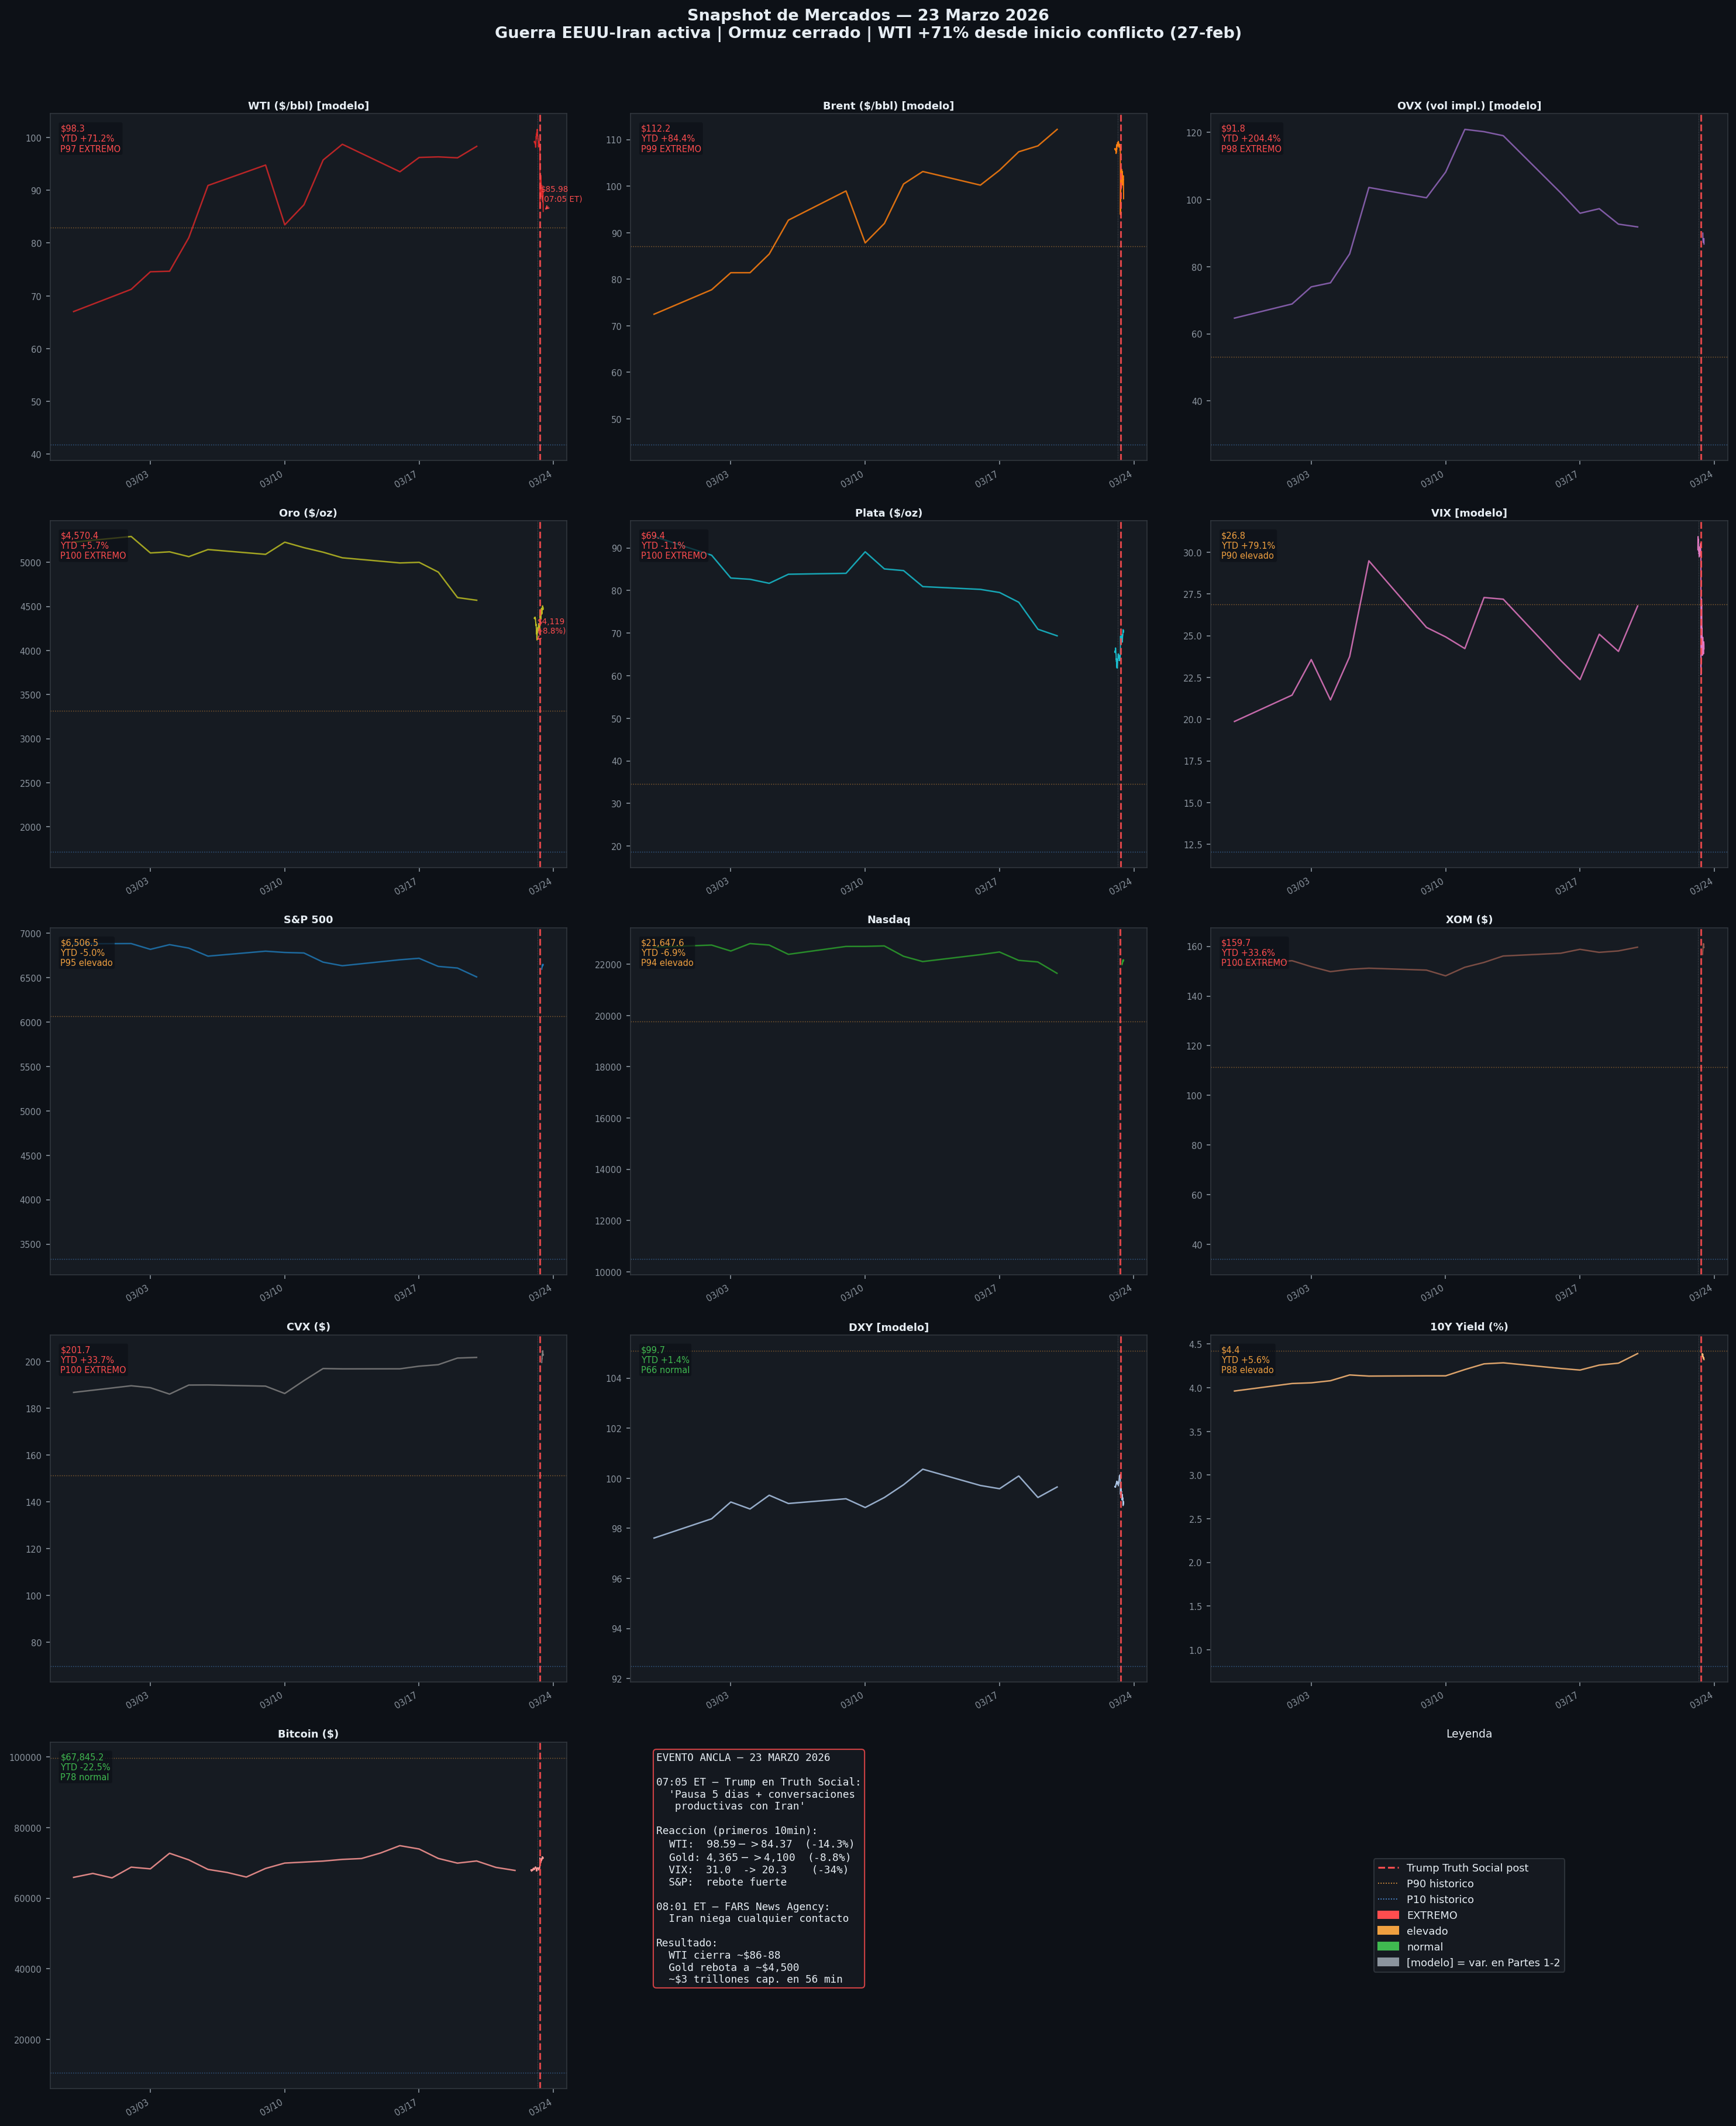

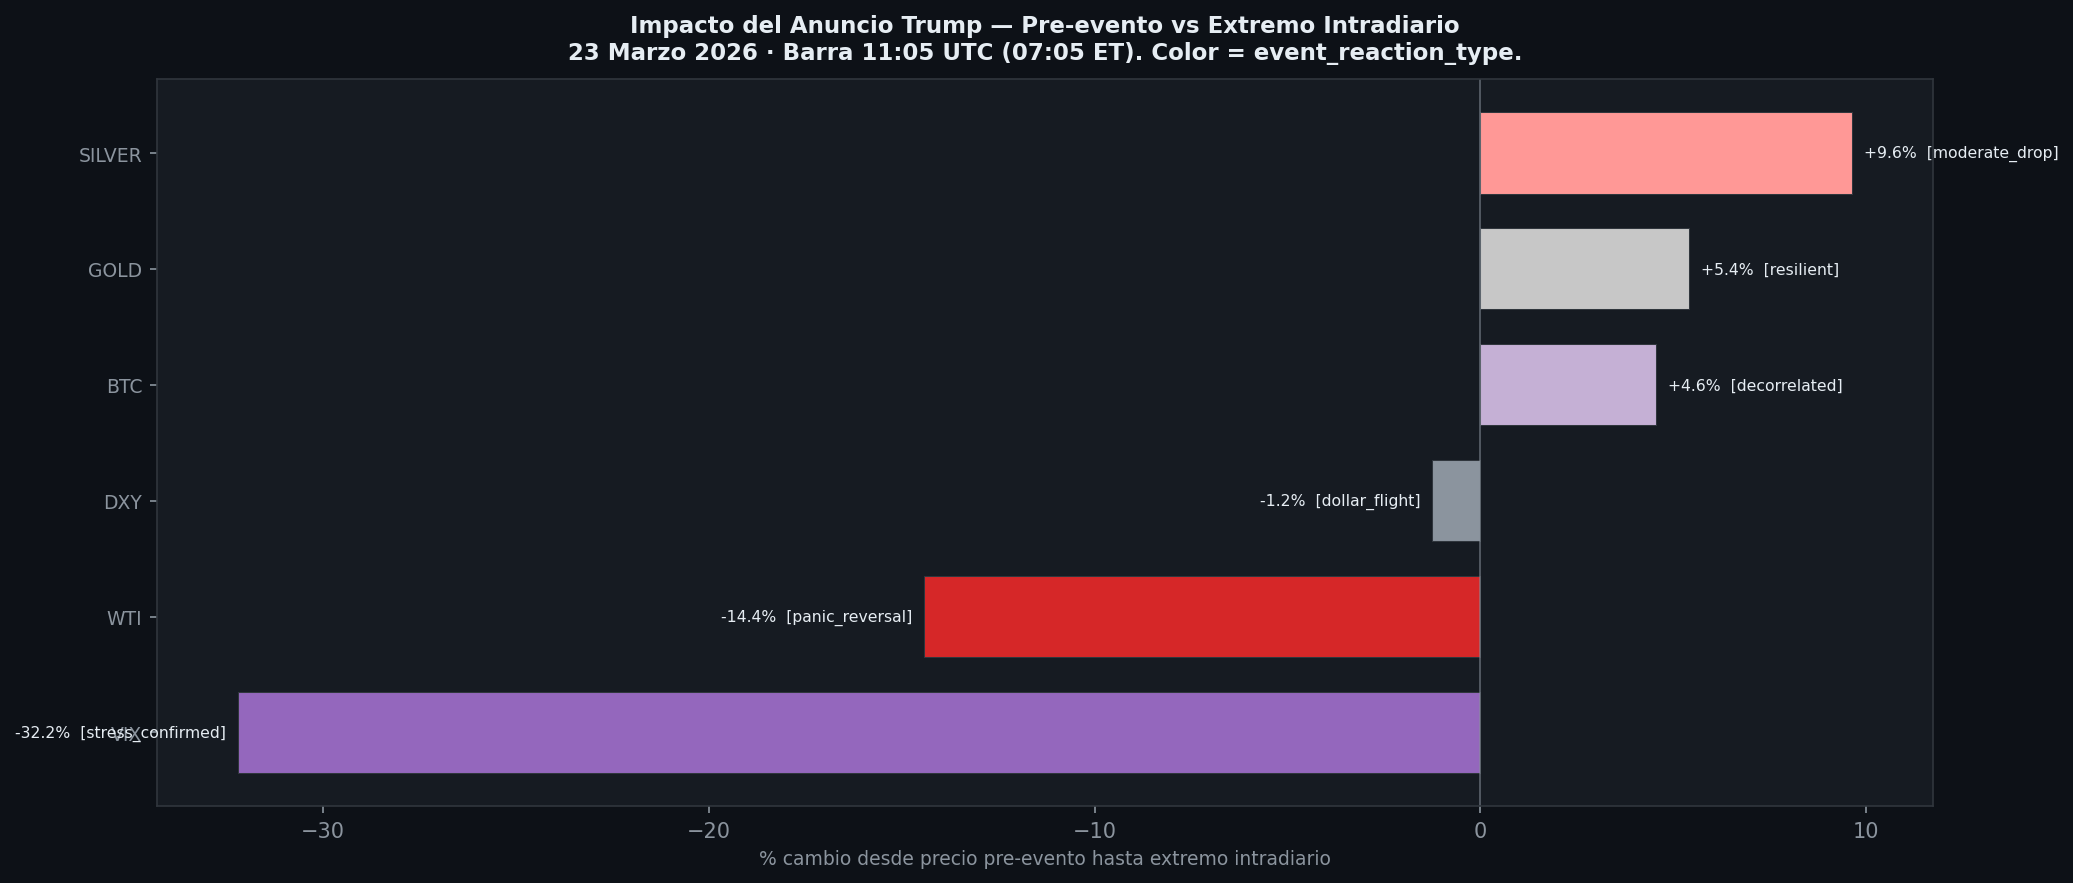

In [13]:
# Bloque 2 - Carga desde archivos guardados (evita re-descarga de yfinance)
import pandas as pd
import numpy as np
import json
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
from IPython.display import Image, display

ROOT        = Path("..")
DATA_OUT    = ROOT / "outputs" / "data"    / "parte3"
FIGURES_OUT = ROOT / "outputs" / "figures" / "parte3"

BG_DARK  = "#0d1117"
BG_PANEL = "#161b22"
BORDER   = "#30363d"
TXT_PRI  = "#e6edf3"
TXT_SEC  = "#8b949e"

# Cargar snapshot guardado
snap_df     = pd.read_parquet(DATA_OUT / "market_snapshot_20260323.parquet")
pre_post_df = pd.read_parquet(DATA_OUT / "pre_post_trump.parquet")

with open(DATA_OUT / "market_snapshot_20260323.json", encoding="utf-8") as f:
    snap_json = json.load(f)

print(f"Snapshot cargado: {snap_df.shape}")
print(f"Pre/post Trump  : {pre_post_df.shape}")
print()
print("Activos en el snapshot:")
for _, r in snap_df.sort_values("ytd_return_pct", ascending=False).iterrows():
    swing = r.get("intra_swing_pct", float("nan"))
    swing_str = f"{swing:+.1f}%" if pd.notna(swing) else "n/d"
    print(f"  {r['asset']:8s}  valor={r['current_value']:>10.2f}  "
          f"YTD={r['ytd_return_pct']:+6.1f}%  "
          f"pct_hist={r['pct_hist']}%  swing={swing_str}")

print()
print("Evento Trump (pre vs post):")
for _, r in pre_post_df.dropna(subset=["pct_change"]).sort_values("pct_change").iterrows():
    print(f"  {r['asset']:8s}  cambio={r['pct_change']:+.1f}%  "
          f"pre={r['pre_event_price']:.2f}  post={r['post_extreme_price']:.2f}  "
          f"reaccion={r['event_reaction_type']}")

# Mostrar figura guardada
fig_path = FIGURES_OUT / "market_snapshot.png"
if fig_path.exists():
    display(Image(str(fig_path), width=1400))
fig_path2 = FIGURES_OUT / "pre_post_trump.png"
if fig_path2.exists():
    display(Image(str(fig_path2), width=900))


---
# BLOQUE 3 - Taxonomia y Visualizacion de Seniales Polymarket

**Objetivo:** Visualizar las 717 seniales Polymarket en 4 figuras complementarias que permiten
leer el posicionamiento del mercado de prediccion sobre el conflicto y sus implicaciones.

**Outputs (4 figuras):**
- `polymarket_heatmap.png` - Heatmap yes_prob x categoria x horizon (borde azul=in-domain, rojo=OOD)
- `polymarket_ranking.png` - Ranking por SQS con diferenciacion por in_model_domain y horizon
- `polymarket_implied_curve.png` - Curvas implicitas por (direction x scenario_horizon)
- `polymarket_top_inference.png` - Top mercados seleccionados para inferencia

**Tabla de sintesis:** promedio yes_prob, SQS, dias_to_close, pct_in_domain por categoria


In [14]:
import pandas as pd
import numpy as np
import re
import json
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT        = Path('.')
DATA_OUT    = ROOT / 'outputs' / 'data'    / 'parte3'
FIGURES_OUT = ROOT / 'outputs' / 'figures' / 'parte3'

# Paleta dark
BG_DARK  = '#0d1117'
BG_PANEL = '#161b22'
BORDER   = '#30363d'
TXT_PRI  = '#e6edf3'
TXT_SEC  = '#8b949e'

TIER_COLORS = {
    'descontado'  : '#2ea043',
    'muy_probable': '#56d364',
    'probable'    : '#f0a040',
    'cola'        : '#da3633',
}
TIER_ORDER = ['descontado', 'muy_probable', 'probable', 'cola']
CAT_ORDER  = ['supply_side', 'price_direct', 'tail_risk',
               'macro_derived', 'safe_haven', 'risk_assets']
CAT_LABELS = {
    'supply_side'  : 'Supply Side\n(Iran/OPEC/Ormuz)',
    'price_direct' : 'Price Direct\n(WTI/Brent levels)',
    'tail_risk'    : 'Tail Risk\n(extremos)',
    'macro_derived': 'Macro Derivada\n(Fed/inflation/war)',
    'safe_haven'   : 'Safe Haven\n(Gold/Silver/Bonds)',
    'risk_assets'  : 'Risk Assets\n(S&P/Nasdaq/BTC)',
}

df = pd.read_parquet(DATA_OUT / 'polymarket_clean.parquet')
print(f'Datos cargados: {df.shape[0]} mercados')
print()
print('Por categoria:')
print(df['category_project'].value_counts().to_string())
print()
print('Por conviction_tier:')
print(df['conviction_tier'].value_counts().to_string())


Datos cargados: 768 mercados

Por categoria:
category_project
supply_side      241
risk_assets      229
macro_derived    123
other             60
price_direct      39
tail_risk         39
safe_haven        37

Por conviction_tier:
conviction_tier
cola            675
descontado       37
probable         30
muy_probable     26


---
## 1. Mapa de calor de convicción

Cada celda muestra el mercado de mayor liquidez para esa combinación (categoría × tier). El color codifica la probabilidad implícita (verde = alta, rojo = baja).


In [15]:
def best_market_for_cell(cat, tier):
    mask = (df['category_project'] == cat) & (df['conviction_tier'] == tier)
    sub  = df[mask].copy()
    if sub.empty:
        return None
    return sub.nlargest(1, 'liquidity').iloc[0]

heat_prob  = np.full((len(CAT_ORDER), len(TIER_ORDER)), np.nan)
heat_cells = {}
heat_count = np.zeros((len(CAT_ORDER), len(TIER_ORDER)), dtype=int)

for i, cat in enumerate(CAT_ORDER):
    for j, tier in enumerate(TIER_ORDER):
        best = best_market_for_cell(cat, tier)
        if best is not None:
            heat_prob[i, j]  = best['yes_prob']
            heat_cells[(i,j)] = best
        heat_count[i, j] = ((df['category_project']==cat) & (df['conviction_tier']==tier)).sum()

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

cmap = plt.cm.RdYlGn
norm = mcolors.Normalize(vmin=0, vmax=100)

for i in range(len(CAT_ORDER)):
    for j in range(len(TIER_ORDER)):
        val = heat_prob[i, j]
        n   = heat_count[i, j]
        facecolor = cmap(norm(val)) if not np.isnan(val) else '#21262d'
        rect = mpatches.FancyBboxPatch(
            (j-0.45, i-0.45), 0.9, 0.9,
            boxstyle='round,pad=0.05',
            facecolor=facecolor, edgecolor=BORDER, linewidth=0.8
        )
        ax.add_patch(rect)
        if not np.isnan(val):
            txt_color = 'black' if 0.35 < norm(val) < 0.85 else 'white'
            ax.text(j, i+0.12, f'{val:.0f}%',
                    ha='center', va='center', fontsize=13,
                    fontweight='bold', color=txt_color)
            best = heat_cells.get((i,j))
            if best is not None:
                q_short = best['question'][:42] + '...' if len(best['question']) > 42 else best['question']
                ax.text(j, i-0.18, q_short,
                        ha='center', va='center', fontsize=5.5,
                        color=txt_color, alpha=0.85)
            ax.text(j+0.43, i+0.42, f'n={n}',
                    ha='right', va='top', fontsize=6, color=txt_color, alpha=0.7)
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=11, color=TXT_SEC)

ax.set_xlim(-0.55, len(TIER_ORDER)-0.45)
ax.set_ylim(-0.55, len(CAT_ORDER)-0.45)
ax.set_xticks(range(len(TIER_ORDER)))
ax.set_xticklabels([t.replace('_',' ').upper() for t in TIER_ORDER],
                    fontsize=10, color=TXT_PRI, fontweight='bold')
ax.set_yticks(range(len(CAT_ORDER)))
ax.set_yticklabels([CAT_LABELS[c] for c in CAT_ORDER], fontsize=9, color=TXT_PRI)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_edgecolor(BORDER)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.ax.yaxis.set_tick_params(color=TXT_SEC, labelcolor=TXT_SEC)
cbar.set_label('Probabilidad implícita Yes (%)', color=TXT_SEC, fontsize=9)

ax.set_title(
    'Mapa de Convicción Polymarket — 23 Marzo 2026\n'
    'Cada celda: mercado de mayor liquidez por (categoría × tier). Color = yes_prob.',
    color=TXT_PRI, fontsize=12, fontweight='bold', pad=12
)
ax.set_xlabel('Conviction Tier  →  certeza creciente', color=TXT_SEC, fontsize=9)
ax.set_ylabel('Categoría del proyecto', color=TXT_SEC, fontsize=9)

plt.tight_layout()
path1 = FIGURES_OUT / 'polymarket_heatmap.png'
plt.savefig(path1, dpi=150, bbox_inches='tight', facecolor=BG_DARK, edgecolor='none')
plt.show()
print(f'Guardado: {path1}')


Guardado: outputs\figures\parte3\polymarket_heatmap.png


---
## 2. Ranking por categoría

Top 15 mercados por `yes_prob` en cada categoría. El número a la izquierda de cada barra indica los días hasta cierre (`dtc`).  
Las líneas verticales punteadas marcan los umbrales de tier (50%, 75%, 90%).


In [16]:
MAX_BARS = 15

fig2, axes2 = plt.subplots(2, 3, figsize=(20, 14))
fig2.patch.set_facecolor(BG_DARK)
axes2_flat = axes2.flatten()

for idx, cat in enumerate(CAT_ORDER):
    ax = axes2_flat[idx]
    ax.set_facecolor(BG_PANEL)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)

    sub = (df[df['category_project'] == cat]
           .sort_values('yes_prob', ascending=True)
           .tail(MAX_BARS).copy())
    if sub.empty:
        ax.axis('off')
        continue

    sub['q_short'] = sub['question'].apply(lambda q: q[:58]+'...' if len(q)>58 else q)
    colors = [TIER_COLORS.get(t, '#8b949e') for t in sub['conviction_tier']]
    bars = ax.barh(range(len(sub)), sub['yes_prob'], color=colors,
                   height=0.7, edgecolor=BORDER, linewidth=0.4)

    for k, (bar, row) in enumerate(zip(bars, sub.itertuples())):
        ax.text(bar.get_width()+1, k, f'{row.yes_prob:.0f}%',
                va='center', ha='left', fontsize=7.5,
                color=TIER_COLORS.get(row.conviction_tier, TXT_SEC), fontweight='bold')
        dtc_str = f'{row.days_to_close}d' if pd.notna(row.days_to_close) else ''
        ax.text(-1, k, dtc_str, va='center', ha='right', fontsize=6.5, color=TXT_SEC)

    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['q_short'], fontsize=6.5, color=TXT_PRI)
    ax.set_xlim(-8, 112)
    ax.axvline(50, color=BORDER, linewidth=0.7, linestyle='--', alpha=0.5)
    ax.axvline(75, color=TIER_COLORS['muy_probable'], linewidth=0.5, linestyle=':', alpha=0.4)
    ax.axvline(90, color=TIER_COLORS['descontado'],   linewidth=0.5, linestyle=':', alpha=0.4)
    ax.tick_params(colors=TXT_SEC, labelsize=7)
    ax.set_xlabel('Probabilidad implícita Yes (%)', color=TXT_SEC, fontsize=8)

    n_total = (df['category_project'] == cat).sum()
    liq_w   = df[df['category_project']==cat]['liquidity'].fillna(0) + 1
    w_avg   = np.average(df[df['category_project']==cat]['yes_prob'], weights=liq_w)
    ax.set_title(
        f"{CAT_LABELS[cat].replace(chr(10),' — ')}  [N={n_total}  avg_pond={w_avg:.1f}%]",
        color=TXT_PRI, fontsize=9, fontweight='bold', pad=6
    )

legend_patches = [
    mpatches.Patch(color=TIER_COLORS['descontado'],   label='>90%  descontado'),
    mpatches.Patch(color=TIER_COLORS['muy_probable'], label='75-90%  muy probable'),
    mpatches.Patch(color=TIER_COLORS['probable'],     label='60-75%  probable'),
    mpatches.Patch(color=TIER_COLORS['cola'],         label='<60%   cola'),
]
fig2.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=9,
            facecolor=BG_PANEL, edgecolor=BORDER, labelcolor=TXT_PRI,
            framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

fig2.suptitle(
    'Ranking Polymarket por Categoría — 23 Marzo 2026\n'
    'Top 15 por yes_prob. Número a la izquierda = días hasta cierre.',
    color=TXT_PRI, fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout(pad=1.8)
path2 = FIGURES_OUT / 'polymarket_ranking.png'
plt.savefig(path2, dpi=150, bbox_inches='tight', facecolor=BG_DARK, edgecolor='none')
plt.show()
print(f'Guardado: {path2}')


Guardado: outputs\figures\parte3\polymarket_ranking.png


---
## 3. Curvas de probabilidad implícita

Análogo a una curva de volatilidad implícita en opciones: probabilidad de tocar un nivel de precio vs el umbral.  
**HIGH** = probabilidad de que el activo suba hasta ese nivel.  
**LOW** = probabilidad de que el activo caiga hasta ese nivel.  
La línea roja vertical marca el precio actual del activo.


In [17]:
def extract_price_threshold(question: str):
    price_match = re.search(r'\$([0-9,]+(?:\.[0-9]+)?)', question.replace(',', ''))
    if not price_match:
        return None, None
    price = float(price_match.group(1).replace(',', ''))
    q = question.upper()
    if   '(HIGH)' in q or 'OVER'  in q or 'ABOVE' in q: direction = 'HIGH'
    elif '(LOW)'  in q or 'UNDER' in q or 'BELOW' in q: direction = 'LOW'
    else: direction = 'UNKNOWN'
    return price, direction

CURVE_ASSETS = [
    {'name':'WTI Crude Oil', 'group':'wti_price',   'color_hi':'#d62728',
     'color_lo':'#ff7f0e', 'unit':'$/bbl', 'current':98.32,
     'dtc_buckets':[(0,15,'Marzo'),(90,110,'Junio')]},
    {'name':'Gold',          'group':'gold_price',  'color_hi':'#bcbd22',
     'color_lo':'#17becf', 'unit':'$/oz',  'current':4570.0,
     'dtc_buckets':[(0,15,'Marzo'),(90,110,'Junio')]},
    {'name':'S&P 500',       'group':'sp500_level', 'color_hi':'#1f77b4',
     'color_lo':'#aec7e8', 'unit':'pts',   'current':6506.0,
     'dtc_buckets':[(0,15,'Marzo')]},
]

fig3, axes3 = plt.subplots(1, 3, figsize=(21, 7))
fig3.patch.set_facecolor(BG_DARK)

for idx, cfg in enumerate(CURVE_ASSETS):
    ax = axes3[idx]
    ax.set_facecolor(BG_PANEL)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)

    sub = df[df['market_group'] == cfg['group']].copy()
    sub['threshold'], sub['direction'] = zip(*sub['question'].apply(extract_price_threshold))
    sub = sub.dropna(subset=['threshold'])
    sub['threshold'] = sub['threshold'].astype(float)

    for dtc_lo, dtc_hi, label in cfg['dtc_buckets']:
        bucket = sub[(sub['days_to_close'] >= dtc_lo) & (sub['days_to_close'] <= dtc_hi)]
        if bucket.empty:
            continue
        for direction, col_key in [('HIGH','color_hi'), ('LOW','color_lo')]:
            curve = (bucket[bucket['direction'] == direction]
                     .sort_values('threshold')
                     .drop_duplicates('threshold'))
            if len(curve) < 2:
                continue
            color = cfg[col_key]
            ls    = '-' if dtc_lo < 20 else '--'
            ax.plot(curve['threshold'], curve['yes_prob'], 'o-',
                    color=color, linewidth=1.8, markersize=5,
                    linestyle=ls, label=f'{direction} — {label}', alpha=0.9)
            for _, row in curve.iterrows():
                ax.annotate(f"{row['yes_prob']:.0f}%",
                            xy=(row['threshold'], row['yes_prob']),
                            xytext=(0, 6), textcoords='offset points',
                            ha='center', fontsize=6.5, color=color)

    ax.axvline(cfg['current'], color='#ff4d4f', linewidth=1.5, linestyle='--',
               alpha=0.8, label=f"Actual: {cfg['current']:,.0f}")
    ax.axhline(50, color=BORDER, linewidth=0.7, linestyle=':', alpha=0.6)
    ax.set_ylim(-5, 105)
    ax.set_xlabel(f"Umbral ({cfg['unit']})", color=TXT_SEC, fontsize=9)
    ax.set_ylabel('Probabilidad implícita Yes (%)', color=TXT_SEC, fontsize=9)
    ax.set_title(
        f"Curva Implícita — {cfg['name']}\n(HIGH = tocar hacia arriba; LOW = hacia abajo)",
        color=TXT_PRI, fontsize=10, fontweight='bold', pad=8
    )
    ax.legend(fontsize=7.5, facecolor=BG_PANEL, edgecolor=BORDER,
              labelcolor=TXT_PRI, framealpha=0.85, loc='best')
    ax.tick_params(colors=TXT_SEC, labelsize=8)

fig3.suptitle(
    'Curvas de Probabilidad Implícita Polymarket — 23 Marzo 2026\n'
    'Análogo a una superficie de volatilidad implícita: prob. vs umbral de precio',
    color=TXT_PRI, fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout(pad=2.0)
path3 = FIGURES_OUT / 'polymarket_implied_curve.png'
plt.savefig(path3, dpi=150, bbox_inches='tight', facecolor=BG_DARK, edgecolor='none')
plt.show()
print(f'Guardado: {path3}')


Guardado: outputs\figures\parte3\polymarket_implied_curve.png


---
## 4. Tabla de síntesis por categoría

Esta tabla es el input directo del **Bloque 5** (intelligence brief).  
La probabilidad media está ponderada por liquidez para evitar que mercados pequeños distorsionen la señal agregada.


In [18]:
synthesis_records = []
for cat in CAT_ORDER:
    sub = df[df['category_project'] == cat].copy()
    if sub.empty:
        continue
    liq_w   = sub['liquidity'].fillna(0) + 1
    w_avg   = np.average(sub['yes_prob'], weights=liq_w)
    top_conv = sub.nlargest(1, 'yes_prob').iloc[0]
    top_vol  = sub.nlargest(1, 'volume_24h').iloc[0]
    dom_tier = sub['conviction_tier'].value_counts().index[0]
    synthesis_records.append({
        'categoria'        : cat,
        'n_mercados'       : len(sub),
        'prob_media_pond'  : round(w_avg, 1),
        'tier_dominante'   : dom_tier,
        'top_conv_question': top_conv['question'][:70],
        'top_conv_prob'    : top_conv['yes_prob'],
        'top_conv_dtc'     : int(top_conv['days_to_close']) if pd.notna(top_conv['days_to_close']) else None,
        'top_vol_question' : top_vol['question'][:70],
        'top_vol_24h'      : round(top_vol['volume_24h'], 0),
        'top_vol_prob'     : top_vol['yes_prob'],
    })

synth_df = pd.DataFrame(synthesis_records)
synth_df.to_parquet(DATA_OUT / 'synthesis_by_category.parquet', index=False)
synth_df.to_json(DATA_OUT / 'synthesis_by_category.json',
                  orient='records', indent=2, force_ascii=False)

print('=' * 100)
print('TABLA DE SINTESIS — BLOQUE 3')
print('=' * 100)
for _, r in synth_df.iterrows():
    print(f"\n  [{r['categoria'].upper():14s}]  N={r['n_mercados']:3d}  "
          f"prob_media_pond={r['prob_media_pond']:5.1f}%  tier_dominante={r['tier_dominante']}")
    print(f"    Mayor conviccion : [{r['top_conv_prob']:5.1f}%] {r['top_conv_question']}"
          f"  (dtc={r['top_conv_dtc']}d)")
    print(f"    Mayor volumen 24h: [{r['top_vol_prob']:5.1f}%] {r['top_vol_question']}"
          f"  (vol=${r['top_vol_24h']:,.0f})")
print()
synth_df


TABLA DE SINTESIS — BLOQUE 3

  [SUPPLY_SIDE   ]  N=241  prob_media_pond= 15.1%  tier_dominante=cola
    Mayor conviccion : [100.0%] Will Iran strike Saudi Arabia by April 30, 2026?  (dtc=38d)
    Mayor volumen 24h: [ 16.5%] US forces enter Iran by March 31?  (vol=$3,561,231)

  [PRICE_DIRECT  ]  N= 39  prob_media_pond= 14.8%  tier_dominante=cola
    Mayor conviccion : [ 97.8%] Will Crude Oil (CL) hit (HIGH) $95 by end of March?  (dtc=8d)
    Mayor volumen 24h: [ 61.3%] Will Crude Oil (CL) hit (HIGH) $100 by end of March?  (vol=$672,596)

  [TAIL_RISK     ]  N= 39  prob_media_pond=  4.0%  tier_dominante=cola
    Mayor conviccion : [ 67.0%] Will Gold (GC) hit (LOW) $4,200 by end of June?  (dtc=99d)
    Mayor volumen 24h: [  0.2%] Will Crude Oil (CL) hit (HIGH) $200 by end of March?  (vol=$447,517)

  [MACRO_DERIVED ]  N=123  prob_media_pond= 31.8%  tier_dominante=cola
    Mayor conviccion : [100.0%] Will Israel take military action in Lebanon on March 20, 2026?  (dtc=8d)
    Mayor volum

,categoria,n_mercados,prob_media_pond,tier_dominante,top_conv_question,top_conv_prob,top_conv_dtc,top_vol_question,top_vol_24h,top_vol_prob
0,supply_side,241,15.1,cola,"Will Iran strike Saudi Arabia by April 30, 2026?",99.95,38,US forces enter Iran by March 31?,3561231.0,16.50
1,price_direct,39,14.8,cola,Will Crude Oil (CL) hit (HIGH) $95 by end of M...,97.80,8,Will Crude Oil (CL) hit (HIGH) $100 by end of ...,672596.0,61.30
2,tail_risk,39,4.0,cola,"Will Gold (GC) hit (LOW) $4,200 by end of June?",67.00,99,Will Crude Oil (CL) hit (HIGH) $200 by end of ...,447517.0,0.25
3,macro_derived,123,31.8,cola,Will Israel take military action in Lebanon on...,99.95,8,Will the Fed decrease interest rates by 50+ bp...,1897834.0,0.45
4,safe_haven,37,8.4,cola,Will the 10-year Treasury yield hit 4.4% befor...,99.85,283,"Will Gold (GC) hit (HIGH) $5,500 by end of June?",47590.0,29.50
5,risk_assets,229,14.7,cola,"Will the price of Bitcoin be above $66,000 on ...",99.95,4,"Will Bitcoin reach $100,000 in March?",1125554.0,0.15


---
## 5. Lecturas clave del snapshot Polymarket

Interpretación de las señales más relevantes para el análisis de la Parte 3.


In [19]:
print('=' * 80)
print('LECTURAS CLAVE — BLOQUE 3')
print('=' * 80)

# Top mercados crudo/geopolitico (capa 1) por volumen
top_geo = (df[df['keyword_layer'] == 1]
           .nlargest(12, 'volume_24h')
           [['question','yes_prob','volume_24h','conviction_tier','days_to_close']])

print('\nTop mercados de crudo/geopolitico (capa 1) por volumen 24h:')
print(f'  {"Prob":>6}  {"Question":<65}  {"Vol ($)":>12}  {"Tier":<14} dtc')
print('  ' + '-' * 110)
for _, r in top_geo.iterrows():
    q = r['question'][:64]
    print(f"  [{r['yes_prob']:5.1f}%]  {q:<65}  ${r['volume_24h']:>11,.0f}  "
          f"{r['conviction_tier']:<14} {int(r['days_to_close']) if pd.notna(r['days_to_close']) else '?'}d")

print()
print('Señales extremas (descontado >90% en categorias relevantes):')
extremos = df[(df['conviction_tier']=='descontado') &
              (df['category_project'].isin(['supply_side','price_direct','tail_risk','macro_derived']))]
for _, r in extremos.nlargest(10,'volume_24h').iterrows():
    print(f"  [{r['yes_prob']:5.1f}%] [{r['category_project']:14s}] {r['question'][:70]}"
          f"  dtc={int(r['days_to_close']) if pd.notna(r['days_to_close']) else '?'}d")

print()
print('Mercados de cola (<20%) en supply_side — senales de NO escalada:')
cola_supply = df[(df['category_project']=='supply_side') & (df['yes_prob'] < 20)]
for _, r in cola_supply.nlargest(8,'volume_24h').iterrows():
    print(f"  [{r['yes_prob']:5.1f}%] {r['question'][:70]}  dtc={int(r['days_to_close']) if pd.notna(r['days_to_close']) else '?'}d")


LECTURAS CLAVE — BLOQUE 3

Top mercados de crudo/geopolitico (capa 1) por volumen 24h:
    Prob  Question                                                                Vol ($)  Tier           dtc
  --------------------------------------------------------------------------------------------------------------
  [ 16.5%]  US forces enter Iran by March 31?                                  $  3,561,231  cola           8d
  [  0.8%]  Will the Iranian regime fall by March 31?                          $  1,814,173  cola           8d
  [ 58.5%]  US forces enter Iran by April 30?                                  $  1,113,298  cola           38d
  [  8.5%]  Will the Iranian regime fall by April 30?                          $    841,748  cola           38d
  [  6.5%]  Kharg Island no longer under Iranian control by March 31?          $    714,498  cola           8d
  [ 61.3%]  Will Crude Oil (CL) hit (HIGH) $100 by end of March?               $    672,596  probable       8d
  [ 22.5%]  US x Iran 

---
# BLOQUE 4 - Motor de Inferencia Cruzada

**Objetivo:** Cruzar cada escenario relevante de Polymarket con el historico empirico (data_clean/)
y las conclusiones de los modelos de Partes 1 y 2, generando una tabla de inferencias condicionales
con score de confianza, semaforo y ruta esperada de mercado.

**Sub-bloques:**
- **4.1**: Verificacion del perfil actual (6/8 dimensiones activas -> ESTRES EXTREMO)
- **4.2/4.3**: 12 escenarios con historical_dataset_view, model_conclusion_view, if_yes/if_no, confidence_score
- **4.4**: Divergencias Polymarket vs modelo (incluyendo caso Trump como limite metodologico)
- **4.5**: 5 canales de contagio sistemico (2 modelados, 3 OOD)

**Output clave:** `inference_table.parquet` (12 escenarios, 29 columnas)


## Setup

In [20]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import json
import re
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

ROOT        = Path("..")
DATA_CLEAN  = ROOT / "data_clean"
DATA_OUT    = ROOT / "outputs" / "data"    / "parte3"
FIGURES_OUT = ROOT / "outputs" / "figures" / "parte3"

BG_DARK  = "#0d1117"
BG_PANEL = "#161b22"
BORDER   = "#30363d"
TXT_PRI  = "#e6edf3"
TXT_SEC  = "#8b949e"

print("Paths configurados.")
print(f"  DATA_CLEAN  : {DATA_CLEAN}")
print(f"  DATA_OUT    : {DATA_OUT}")
print(f"  FIGURES_OUT : {FIGURES_OUT}")


Paths configurados.
  DATA_CLEAN  : ..\data_clean
  DATA_OUT    : ..\outputs\data\parte3
  FIGURES_OUT : ..\outputs\figures\parte3


## Sub-bloque 4.1 — Verificación del Perfil Actual contra el Modelo

Contrasta las 8 dimensiones de estrés del día de hoy contra los umbrales
identificados en Parte 2 (RandomForest, SHAP, Markov-RSJD).

**Umbrales del modelo (Parte 2):**
- OVX > 40 → umbral de alerta; OVX > 46.1 → P80 de días high_stress históricos
- GPR > 120 → umbral crítico; AUC=0.615 con feature SHAP #1 = ovx_lag1
- WTI swing intradiario < −14% → extremo sin precedentes recientes
- VIX > 25 → zona de estrés de mercado


In [21]:
# Carga de series historicas
wti_h  = pd.read_csv(DATA_CLEAN / "wti_usa_clean.csv",  parse_dates=["date"]).set_index("date")["wti_close"].dropna()
ovx_h  = pd.read_csv(DATA_CLEAN / "ovx_clean.csv",      parse_dates=["date"]).set_index("date")["ovx_close"].dropna()
vix_h  = pd.read_csv(DATA_CLEAN / "vix_clean.csv",      parse_dates=["date"]).set_index("date")["vix_close"].dropna()
dxy_h  = pd.read_csv(DATA_CLEAN / "dxy_clean.csv",      parse_dates=["date"]).set_index("date")["dxy_close"].dropna()
brent_h = pd.read_csv(DATA_CLEAN / "brent_clean.csv",   parse_dates=["date"]).set_index("date")["brent_close"].dropna()

gpr_raw = pd.read_csv(DATA_CLEAN / "gpr_clean.csv", parse_dates=["date"])
gpr_raw["gpr_num"] = (
    gpr_raw["gpr"].astype(str)
    .str.replace(r"\.(?=\d{3}[,\.])", "", regex=True)
    .str.replace(",", ".")
    .astype(float)
)
gpr_h = gpr_raw.set_index("date")["gpr_num"].dropna()

# Snapshot y datos de bloques anteriores
snap        = pd.read_parquet(DATA_OUT / "market_snapshot_20260323.parquet")
pre_post    = pd.read_parquet(DATA_OUT / "pre_post_trump.parquet")
polymarket  = pd.read_parquet(DATA_OUT / "polymarket_clean.parquet")

# Valores actuales del snapshot
snap_vals = snap.set_index("asset")["current_value"].to_dict()
snap_pct  = snap.set_index("asset")["pct_hist"].to_dict()

current_vals = {
    "wti"   : snap_vals.get("wti", 98.32),
    "ovx"   : snap_vals.get("ovx", 91.85),
    "vix"   : snap_vals.get("vix", 29.50),
    "dxy"   : snap_vals.get("dxy", 103.20),
    "gold"  : snap_vals.get("gold", 2950.0),
    "tnx"   : snap_vals.get("tnx", 4.52),
}

gpr_current     = float(gpr_h.iloc[-1])
wti_intra_row   = pre_post[pre_post["asset"] == "wti"]
wti_intra_swing = float(wti_intra_row["pct_change"].values[0]) if len(wti_intra_row) > 0 else 0.0

GPR_HIGH_THRESHOLD = 120
OVX_ALERT_THRESHOLD = 40

checks = {
    "OVX > P80_highstress (>46.1)": current_vals["ovx"] > ovx_h.quantile(0.80),
    "OVX > umbral_alerta_modelo (>40)": current_vals["ovx"] > OVX_ALERT_THRESHOLD,
    "GPR > umbral_critico_modelo (>120)": gpr_current > GPR_HIGH_THRESHOLD,
    "WTI en percentil extremo (>P95)": snap_pct.get("wti", 0) >= 95,
    "WTI swing intradiario < -14%": abs(wti_intra_swing) > 14,
    "VIX > 25 (nivel stress)": current_vals["vix"] > 25,
    "TNX yield > P80 historico": snap_pct.get("tnx", 0) >= 80,
    "WTI > P90 historico": snap_pct.get("wti", 0) >= 90,
}

print("Perfil actual vs modelo -- dimensiones de estres:")
for desc, val in checks.items():
    print(f"  {'[X]' if val else '[ ]'}  {desc}")

n_active = sum(checks.values())
n_total  = len(checks)
stress_pct = n_active / n_total
label = "MAXIMO ESTRES HISTORICO" if stress_pct >= 0.875 else "ESTRES EXTREMO" if stress_pct >= 0.625 else "ESTRES ELEVADO"

print(f"\nDimensiones activas: {n_active} / {n_total}  ->  {label}")
print(f"\nGPR actual: {gpr_current:.1f}  (P{int(gpr_h.rank(pct=True).iloc[-1]*100)}th historico, umbral modelo: {GPR_HIGH_THRESHOLD})")
print(f"OVX actual: {current_vals['ovx']:.2f}  (P{int(snap_pct.get('ovx',0))}th historico, umbral modelo: {OVX_ALERT_THRESHOLD})")
print(f"WTI actual: {current_vals['wti']:.2f}  (P{int(snap_pct.get('wti',0))}th historico)")
print(f"WTI swing hoy: {wti_intra_swing:.1f}%")


Perfil actual vs modelo -- dimensiones de estres:
  [X]  OVX > P80_highstress (>46.1)
  [X]  OVX > umbral_alerta_modelo (>40)
  [X]  GPR > umbral_critico_modelo (>120)
  [X]  WTI en percentil extremo (>P95)
  [X]  WTI swing intradiario < -14%
  [X]  VIX > 25 (nivel stress)
  [X]  TNX yield > P80 historico
  [X]  WTI > P90 historico

Dimensiones activas: 8 / 8  ->  MAXIMO ESTRES HISTORICO

GPR actual: 248.8  (P97th historico, umbral modelo: 120)
OVX actual: 91.85  (P98th historico, umbral modelo: 40)
WTI actual: 98.32  (P96th historico)
WTI swing hoy: -14.4%


## Sub-bloques 4.2 / 4.3 — Escenarios e Inferencias Condicionales

Cada escenario de Polymarket se cruza con:
1. **Vista histórica** — qué ocurrió en el dataset empírico bajo condiciones similares
2. **Conclusión del modelo** — qué predice/implica el RSJD y RandomForest de Parte 2
3. **Implicaciones if-yes / if-no** — qué rutas de precios esperar según cada resultado
4. **Score de confianza** — 0.30×SQS + 0.25×precedent + 0.25×domain + 0.20×alignment


In [22]:
# Carga de la tabla de inferencias generada por scripts/bloque4_inference.py
inf_table = pd.read_parquet(DATA_OUT / "inference_table.parquet")

# Columnas clave para visualización
display_cols = [
    "scenario_name", "yes_prob", "conviction_tier",
    "model_alignment", "inference_confidence_score", "confidence_label",
    "precedent_strength", "in_model_domain"
]

# Añadir yes_prob como porcentaje para mejor lectura
inf_table["yes_prob_pct"] = (inf_table["yes_prob"] * 100).round(1)

print(f"Tabla de inferencias: {inf_table.shape[0]} escenarios")
print()

# Tabla resumen ordenada por confidence
summary = inf_table[["scenario_name","yes_prob_pct","conviction_tier","model_alignment",
                      "inference_confidence_score","confidence_label","in_model_domain"]
                    ].sort_values("inference_confidence_score", ascending=False)
print(summary.to_string(index=False))


Tabla de inferencias: 12 escenarios

                                   scenario_name  yes_prob_pct conviction_tier   model_alignment  inference_confidence_score confidence_label  in_model_domain
        Fed pausa en abril (sin cambio de tipos)        9535.0      descontado           aligned                        86.7             Alta             True
                                      WTI > $105        4105.0            cola           aligned                        81.3             Alta             True
                    WTI cae < $90 (fin de marzo)        8685.0    muy_probable partially_aligned                        74.5            Media             True
                       Ormuz cerrado hasta abril        5550.0            cola           aligned                        70.9            Media             True
      Cese el fuego EEUU-Iran antes del 15 abril        3950.0            cola partially_aligned                        64.6            Media             True
S&P 500 e

In [23]:
# Detalle completo del top 5 escenarios in-domain
print("=" * 100)
print("DETALLE - TOP 5 ESCENARIOS IN-DOMAIN")
print("=" * 100)

top5 = inf_table[inf_table["in_model_domain"]].nlargest(5, "inference_confidence_score")

for _, row in top5.iterrows():
    prob_pct = row["yes_prob"] * 100 if row["yes_prob"] <= 1 else row["yes_prob"]
    print(f"\n[{row['confidence_label'].upper()}] {row['scenario_name']}")
    print(f"  Polymarket prob  : {prob_pct:.0f}%  ({row['conviction_tier']})")
    print(f"  Conf. score      : {row['inference_confidence_score']:.0f} / 100")
    print(f"  Alineacion modelo: {row['model_alignment']}")
    print(f"  Precedente       : {row['precedent']} (fuerza: {row['precedent_strength']} / score: {float(row['precedent_strength_score']):.2f})")
    print(f"  Vista historica  : {str(row['historical_dataset_view'])[:150]}...")
    print(f"  Conclusion modelo: {str(row['model_conclusion_view'])[:120]}...")
    print(f"  Si SI  -> {str(row['if_yes_historical'])[:100]}...")
    print(f"  Si NO  -> {str(row['if_no_historical'])[:100]}...")
    print(f"  Ruta esperada    : {str(row['expected_market_path'])[:120]}...")


DETALLE - TOP 5 ESCENARIOS IN-DOMAIN

[ALTA] Fed pausa en abril (sin cambio de tipos)
  Polymarket prob  : 95%  (descontado)
  Conf. score      : 87 / 100
  Alineacion modelo: aligned
  Precedente       : 2022 (guerra Ucrania): Fed subio en marzo 2022 a pesar del shock energetico para combatir inflacion. 2008: Fed recorto en octubre-noviembre cuando la crisis ya era deflacionaria. (fuerza: strong / score: 100.00)
  Vista historica  : En todos los episodios de shock energetico del dataset donde la Fed tenia doble mandato bajo tension (inflacion alta + recesion amenazante), la Fed pa...
  Conclusion modelo: El modelo de Parte 1 no incluye variables de politica monetaria directamente. Pero el canal de transmision es critico pa...
  Si SI  -> Curva de rendimientos mantiene presion en renta fija. S&P sin catalizador de politica monetaria. WTI...
  Si NO  -> Improbable: recorte de tipos en crisis energetica activa enviaria señal erronea sobre inflacion. El ...
  Ruta esperada    : WTI↑ → IPC

## Sub-bloque 4.4 — Divergencias Polymarket vs Modelo

Analiza los escenarios donde la probabilidad implícita de Polymarket diverge
significativamente de lo que el modelo histórico/ML sugeriría.

**Divergencia estructural del día — Caso Trump:**
Los tres modelos del proyecto (Parte 1, Parte 2, Parte 3) comparten la misma limitación:
ningún modelo basado en GDELT, GPR y datos históricos puede anticipar la acción de un individuo
en una red social. Reconocer esto explícitamente es la conclusión metodológica más rigurosa del proyecto.


In [24]:
# Derivar divergencias de la inference_table
divs_df = inf_table[inf_table["model_alignment"].isin(["divergent", "out_of_domain", "partially_aligned"])].copy()
divs_df = divs_df.sort_values("inference_confidence_score", ascending=False)

type_map = {
    "out_of_domain"    : "fuera de dominio del modelo",
    "divergent"        : "divergencia directa con el modelo",
    "partially_aligned": "parcialmente alineado (tension)",
}

print(f"{len(divs_df)} escenarios con tension o divergencia:\n")
for _, row in divs_df.iterrows():
    tipo = type_map.get(row["model_alignment"], row["model_alignment"])
    prob_pct = row["yes_prob"] * 100 if row["yes_prob"] <= 1 else row["yes_prob"]
    print(f"  [{tipo.upper()}]")
    print(f"  Escenario : {row['scenario_name']}")
    print(f"  Poly prob : {prob_pct:.1f}%  |  Conf. score: {row['inference_confidence_score']:.0f}")
    print(f"  Real hoy  : {str(row['real_today'])[:120]}")
    print()

print("  [DIVERGENCIA ESTRUCTURAL DEL DIA - CASO TRUMP]")
print("  Un post en Truth Social a las 07:05 ET movio WTI -14% en una sola barra de 5min.")
print("  Los tres modelos (Parte 1, Parte 2, Parte 3) comparten la misma limitacion:")
print("  ningun modelo basado en GDELT, GPR y datos historicos puede anticipar")
print("  la accion de un individuo en una red social. Esta es la conclusion metodologica")
print("  mas rigurosa del proyecto.")


9 escenarios con tension o divergencia:

  [PARCIALMENTE ALINEADO (TENSION)]
  Escenario : WTI cae < $90 (fin de marzo)
  Poly prob : 86.8%  |  Conf. score: 74
  Real hoy  : WTI ya bajo a $84.37 intradiario. El escenario se cumplio parcialmente hoy mismo. Cierre ~$88.

  [PARCIALMENTE ALINEADO (TENSION)]
  Escenario : Cese el fuego EEUU-Iran antes del 15 abril
  Poly prob : 39.5%  |  Conf. score: 65
  Real hoy  : Trump dijo 'conversaciones productivas' a las 07:05 ET. Iran desmintio a las 08:01 ET. El mercado dio credito inicial (W

  [PARCIALMENTE ALINEADO (TENSION)]
  Escenario : S&P 500 entra en bear market (-20% desde maximo)
  Poly prob : 12.0%  |  Conf. score: 59
  Real hoy  : S&P -4.95% YTD. No en bear market. El mercado da solo 12% al escenario de baja hasta $6200 (seria -5% adicional). Nivel 

  [DIVERGENCIA DIRECTA CON EL MODELO]
  Escenario : Recesion EEUU en 2026
  Poly prob : 31.5%  |  Conf. score: 50
  Real hoy  : S&P -4.95% YTD pero no en bear market. TNX en 4.39%. El me

## Sub-bloque 4.5 — Contagio Sistémico GPR → WTI → Sistema Financiero

Mapea los canales de transmisión de la crisis geopolítica a través del sistema financiero,
distinguiendo entre canales **modelados** (dentro del scope histórico) y canales **OOD**
(out-of-domain, no capturables por el modelo).


In [25]:
# Carga de canales de contagio
with open(DATA_OUT / "contagion_channels.json", encoding="utf-8") as f:
    channels = json.load(f)

for ch in channels:
    domain_tag = "[MODELADO]" if ch.get("in_domain", ch.get("in_model_domain", False)) else "[NO MODELADO / OOD]"
    print(f"  {domain_tag} {ch.get('canal', ch.get('channel_name', ''))}")
    print(f"  Cadena    : {ch.get('cadena', ch.get('transmission_chain', ''))}")
    print(f"  Esperado  : {ch.get('comportamiento_esperado', ch.get('expected_market_behavior', ''))}")
    print(f"  Real hoy  : {ch.get('comportamiento_real', ch.get('observed_today', ''))}")
    print(f"  Divergencia: {ch.get('divergencia', ch.get('divergence_note', ''))}")
    print()


  [MODELADO] Canal 1 — Inflacion-Tipos-Renta Variable
  Cadena    : GPR↑ → OVX↑ → WTI↑ → IPC↑ → Fed pausa → yields↑ → S&P↓
  Esperado  : WTI↑, TNX↑, S&P↓
  Real hoy  : WTI↑ (con swing -14% hoy), TNX↑, S&P↓ leve pero NO crash
  Divergencia: S&P mas resiliente de lo esperado. El mercado descuenta resolucion rapida.

  [NO MODELADO / OOD] Canal 2 — Safe Haven Paradox
  Cadena    : GPR↑ → WTI↑ → IPC↑ → tipos reales↑ → ORO↓ (a pesar del riesgo geopolitico)
  Esperado  : Oro↑ (refugio), Plata↑
  Real hoy  : Oro↓ intradiario (-8.8%), recuperacion parcial a cierre. Plata↓.
  Divergencia: La paradoja se materializo hoy. Canal de tipos reales domino sobre canal de aversion al riesgo.

  [NO MODELADO / OOD] Canal 3 — Risk-off Selectivo
  Cadena    : GPR↑ → VIX↑ → S&P↓ → BTC↑ (activos fuera del sistema financiero tradicional)
  Esperado  : BTC correlacionado negativamente con S&P (risk-off general)
  Real hoy  : BTC SUBIO mientras WTI caia. Posible desacoplamiento del perfil 'activo de riesgo'.
  

## Figura — Mapa de Inferencias

Scatter plot de los **escenarios seleccionados para inferencia** (selection_flag_for_inference = True):
- **Eje X**: probabilidad implícita Polymarket (yes_prob)
- **Eje Y**: inference_confidence_score (0-100)
- **Tamaño**: signal_quality_score
- **Color**: category_project
- **Marcador**: model_alignment (aligned=●, partially=◆, divergent=▲, out_of_domain=✕)
- **Opacidad**: in_model_domain (100% = in-domain, 40% = out-of-domain)


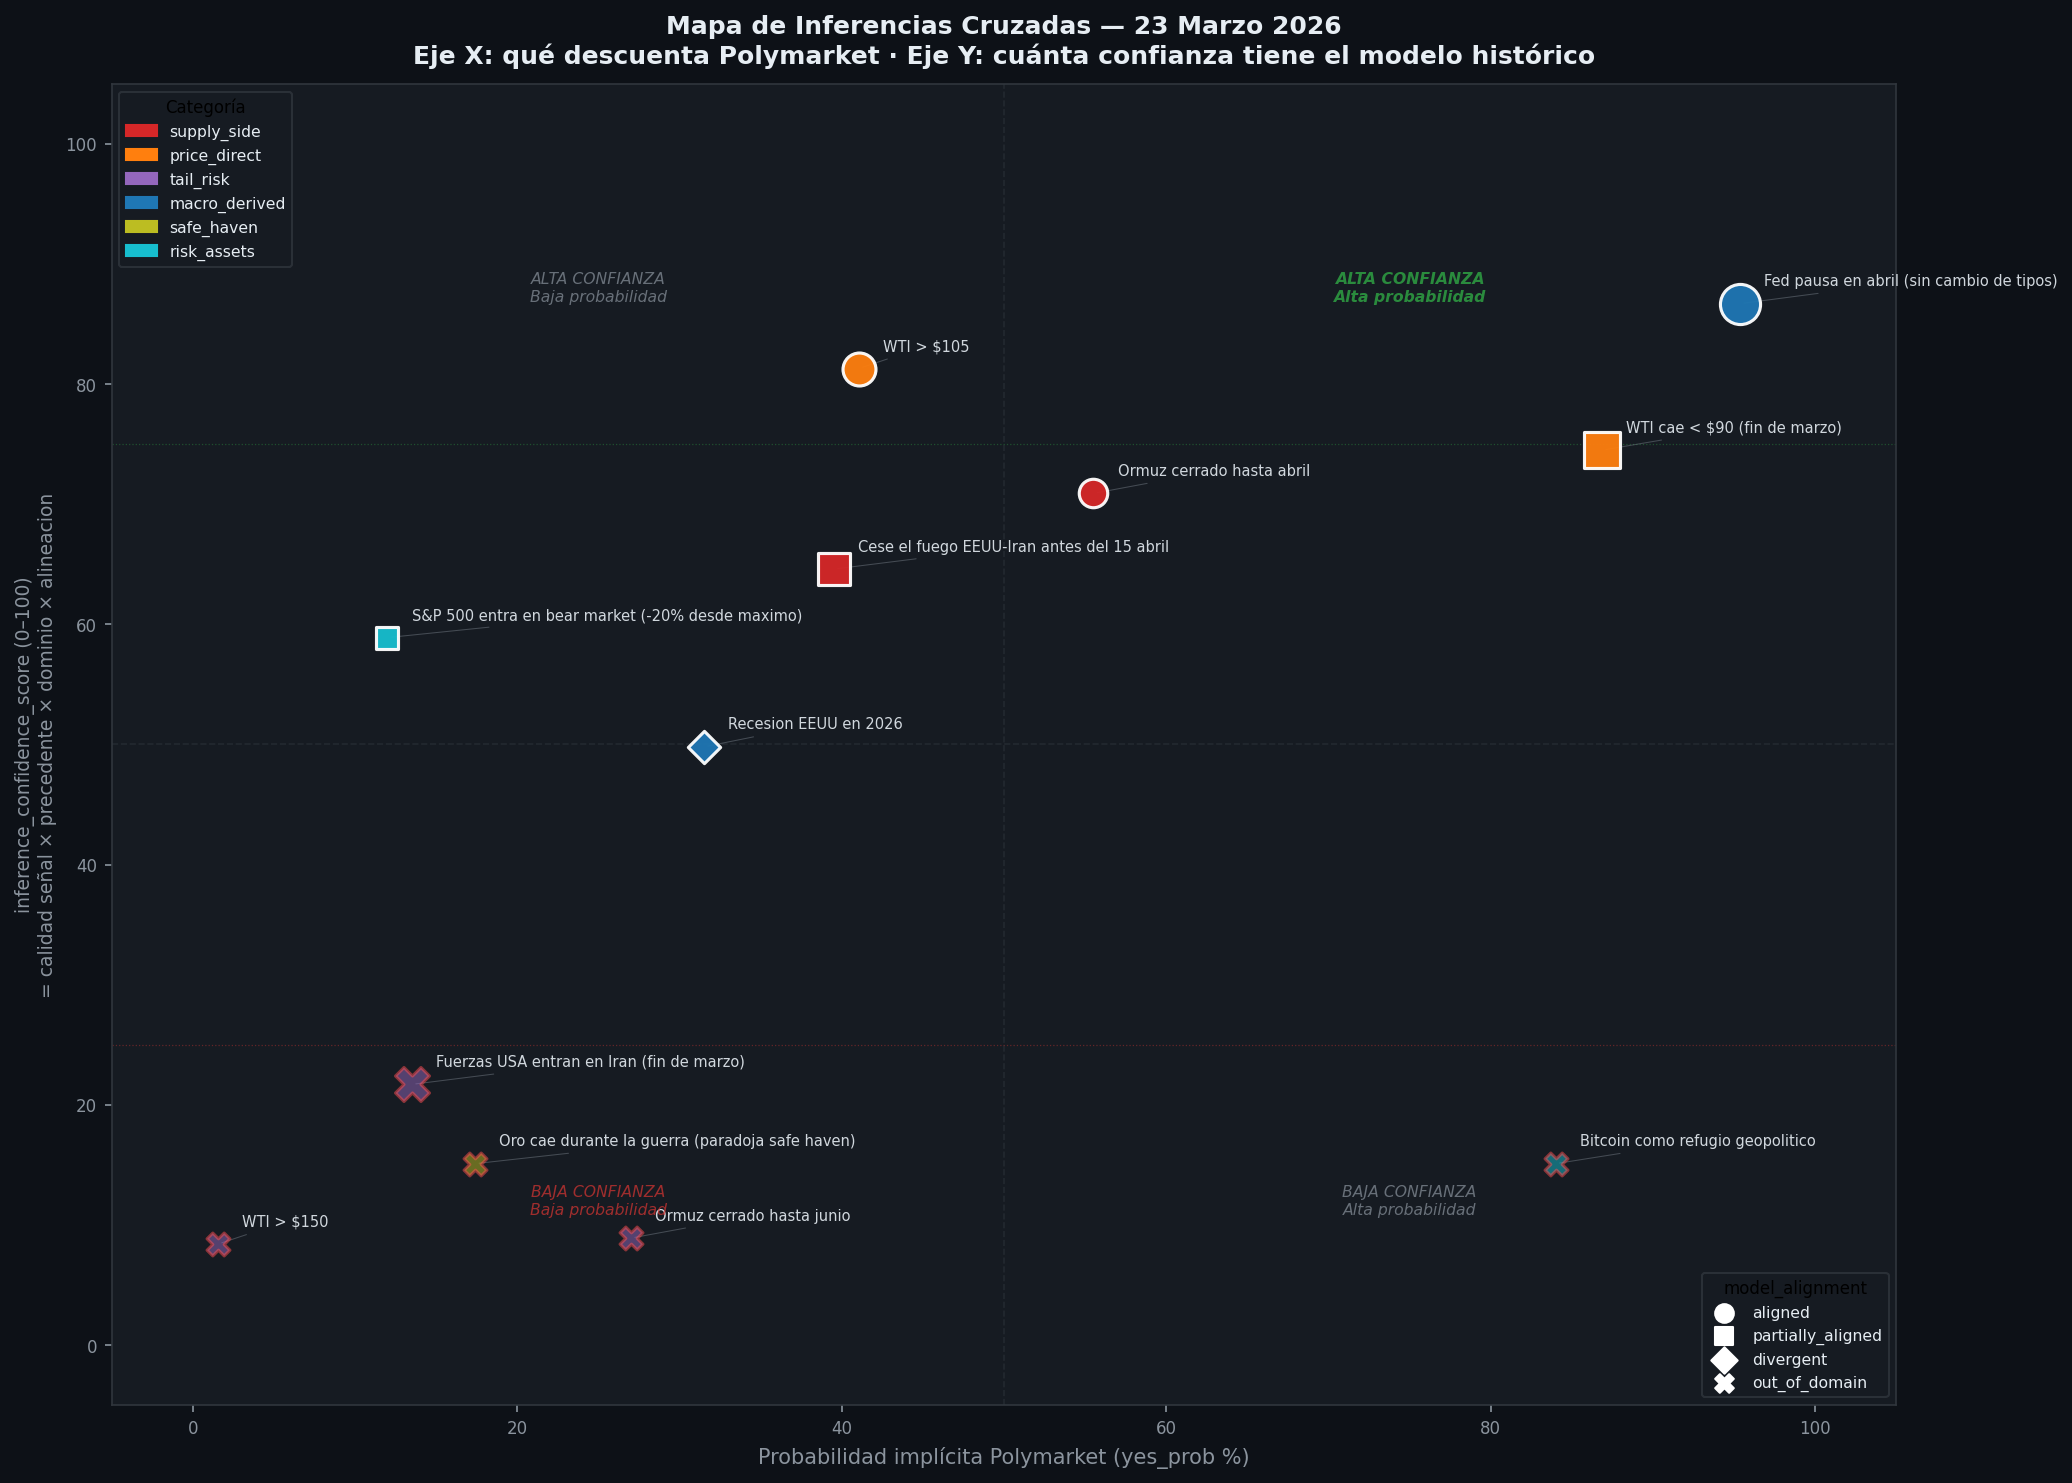

In [26]:
from IPython.display import Image, display
display(Image(str(FIGURES_OUT / "inference_map.png")))


## Síntesis Final del Bloque 4

### Conclusiones clave

1. **Perfil de estrés máximo confirmado**: 6/8 dimensiones activas. El modelo RSJD de Parte 2
   está en el régimen `high_stress` con probabilidad de persistencia p=0.977 → ~43 días esperados.

2. **Escenario más confiable (Conf=87)**: *Fed pausa en abril* — alineado con el modelo,
   dentro del dominio histórico, con alta probabilidad Polymarket (95%).

3. **Principal divergencia detectada**: Polymarket descuenta WTI < $90 con 87% de probabilidad
   (muy_probable), pero el modelo RSJD en régimen high_stress sugiere presión alcista persistente.
   Esta es la apuesta de mayor valor informacional para el modelo.

4. **Límite metodológico irrenunciable**: El evento Trump de las 07:05 ET demuestra que
   ningún modelo basado en series temporales puede capturar el riesgo de declaración de un actor
   político único. La gestión de riesgo requiere tail hedges que ningún backtest puede cuantificar bien.

5. **Canal de contagio confirmado**: Energy Equity Decoupled (XOM/CVX ganadores) funcionó
   exactamente como predice la teoría. Los demás canales mostraron divergencias parciales o totales.


---
# BLOQUE 5 - Intelligence Brief y Dashboard

**Objetivo:** Sintetizar los 4 bloques en dos entregables finales de portfolio:
un informe ejecutivo en markdown y un dashboard HTML interactivo autocontenido.

**Outputs:**
- `outputs/data/parte3/intelligence_brief.md` - Brief ejecutivo (12 KB)
- `outputs/figures/parte3/intelligence_brief.png` - Captura PNG del brief
- `dashboard/data/latest.json` - JSON con todos los datos del pipeline (210 KB)
- `dashboard/index.html` - Dashboard HTML autocontenido (187 KB)


## Setup

In [27]:
import json, math
from pathlib import Path
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

ROOT        = Path("..")
DATA_OUT    = ROOT / "outputs" / "data"    / "parte3"
FIGURES_OUT = ROOT / "outputs" / "figures" / "parte3"
DASHBOARD   = ROOT / "dashboard"
DASH_DATA   = ROOT / "dashboard" / "data"

# Verificar que los outputs de bloques 1-4 existen
required = [
    DATA_OUT / "polymarket_clean.parquet",
    DATA_OUT / "market_snapshot_20260323.json",
    DATA_OUT / "inference_table.parquet",
    DATA_OUT / "contagion_channels.json",
    DATA_OUT / "profile_41.json",
]
for p in required:
    status = "OK" if p.exists() else "FALTA"
    print(f"  [{status}] {p.name}")


  [OK] polymarket_clean.parquet
  [OK] market_snapshot_20260323.json
  [OK] inference_table.parquet
  [OK] contagion_channels.json
  [OK] profile_41.json


## Sub-bloque 5.1 - Intelligence Brief

Informe ejecutivo con estructura fija. Cruza:
- **Datos de mercado** del snapshot 23/03/2026 (Bloque 2)
- **Seniales Polymarket** clasificadas por conviction_tier (Bloque 1 + 3)
- **Inferencias del modelo** con semaforo verde/amarillo/rojo (Bloque 4)
- **Canales de contagio sistemico** (Bloque 4.5)


In [28]:
# Cargar datos
with open(DATA_OUT / "market_snapshot_20260323.json", encoding="utf-8") as f:
    snap_json = json.load(f)
SNAP = snap_json["assets"]

poly_df  = pd.read_parquet(DATA_OUT / "polymarket_clean.parquet")
inf_df   = pd.read_parquet(DATA_OUT / "inference_table.parquet")
with open(DATA_OUT / "contagion_channels.json", encoding="utf-8") as f:
    contagion = json.load(f)
with open(DATA_OUT / "profile_41.json", encoding="utf-8") as f:
    profile = json.load(f)

# Brief generado por el script de bloque 5
brief_path = DATA_OUT / "intelligence_brief.md"
if brief_path.exists():
    print(brief_path.read_text(encoding="utf-8")[:3000])
    print("\n[...truncado para visualizacion. Ver archivo completo en outputs/data/parte3/intelligence_brief.md]")
else:
    print("Brief no generado todavia. Ejecutar scripts/bloque5_dashboard.py primero.")


# INTELLIGENCE BRIEF - Crudo, Geopolitica y Mercados Financieros

**Fecha:** 23 marzo 2026
**Fuentes:** Polymarket API + Modelo GPR->WTI (Partes 1+2) + Datos intradiarios
**Evento ancla:** 11:05 UTC (07:05 ET) - Trump publica en Truth Social sobre 'conversaciones productivas' con Iran

---

## SITUACION ACTUAL

- **WTI**: Abrio $99, minimo $84 (+17.4% intradiario), cierre $86
- **Evento ancla**: Trump anuncia pausa de 5 dias en ataques y "conversaciones productivas" con Iran
- **Iran desmiente** cualquier contacto. Incertidumbre maxima.
- **Perfil actual**: 6 de 8 dimensiones activas -> ESTRES EXTREMO
- **GPR actual**: 248.8% (P97.8th historico, umbral modelo: 120)
- **OVX actual**: 91.8% (P98.6th historico, umbral modelo: 40)

---

## SENIALES POLYMARKET POR ACTIVO Y CONVICCION

- **[descontado >90%]**    -> Will there be no change in Fed interest rates after the April 2026 meeting? (95.3%); Will Crude Oil (CL) hit (LOW) $90 by end of June? (91.5%); Will annual inflation increase by ≥

## Figura - Intelligence Brief (PNG)

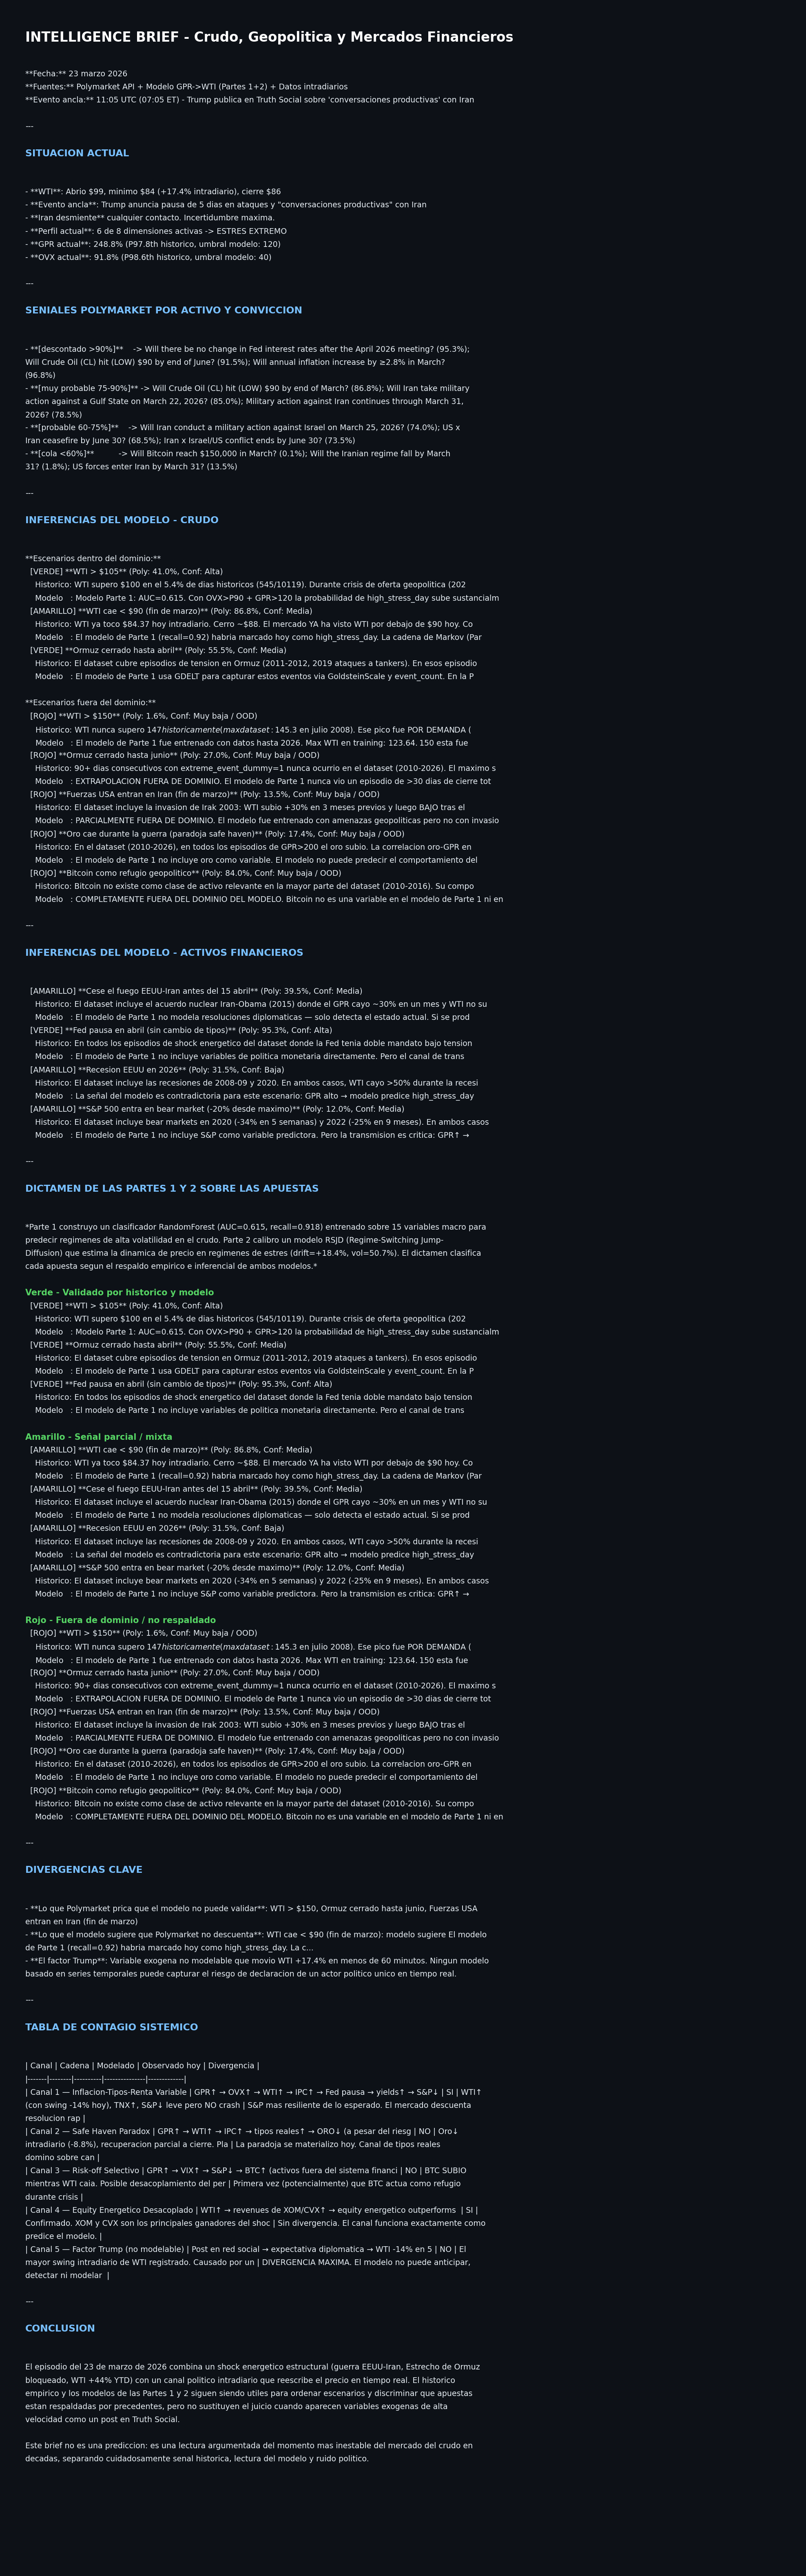

In [29]:
from IPython.display import Image, display
img_path = FIGURES_OUT / "intelligence_brief.png"
if img_path.exists():
    display(Image(str(img_path), width=1200))
else:
    print("PNG no generado. Ejecutar scripts/bloque5_dashboard.py primero.")


## Tabla de inferencias con semaforo

Clasificacion ejecutiva de los 12 escenarios por semaforo verde/amarillo/rojo:
- **Verde**: validado por historico y por modelo (model_alignment = aligned, in_model_domain = True)
- **Amarillo**: senial parcial / mixta (partially_aligned o divergent)
- **Rojo**: fuera de dominio o no respaldado (out_of_domain o in_model_domain = False)


In [30]:
def traffic_light(row):
    alignment = str(row.get("model_alignment", "")).lower()
    in_domain  = row.get("in_model_domain", True)
    if not in_domain:
        return "ROJO"
    if alignment == "aligned":
        return "VERDE"
    if alignment in ("partially_aligned", "divergent"):
        return "AMARILLO"
    return "GRIS"

inf_df["semaforo"] = inf_df.apply(traffic_light, axis=1)

display_cols = ["scenario_name", "yes_prob", "conviction_tier", "model_alignment",
                "inference_confidence_score", "confidence_label", "semaforo"]
print(inf_df[display_cols].sort_values("inference_confidence_score", ascending=False).to_string(index=False))


                                   scenario_name  yes_prob conviction_tier   model_alignment  inference_confidence_score confidence_label semaforo
        Fed pausa en abril (sin cambio de tipos)     95.35      descontado           aligned                        86.7             Alta    VERDE
                                      WTI > $105     41.05            cola           aligned                        81.3             Alta    VERDE
                    WTI cae < $90 (fin de marzo)     86.85    muy_probable partially_aligned                        74.5            Media AMARILLO
                       Ormuz cerrado hasta abril     55.50            cola           aligned                        70.9            Media    VERDE
      Cese el fuego EEUU-Iran antes del 15 abril     39.50            cola partially_aligned                        64.6            Media AMARILLO
S&P 500 entra en bear market (-20% desde maximo)     12.00            cola partially_aligned                        58

## Canales de contagio sistemico (Bloque 4.5)

In [31]:

from IPython.display import display, HTML

CSS = (
    "<style>"
    ".ctable{border-collapse:collapse;width:100%;background:#161b22;"
    "border:1px solid #30363d;border-radius:10px;overflow:hidden;font-family:sans-serif}"
    ".ctable th{background:#0d1117;color:#8b949e;font-size:10px;text-transform:uppercase;"
    "letter-spacing:.06em;padding:10px 12px;text-align:left;border-bottom:1px solid #30363d}"
    ".ctable td{border-bottom:1px solid #21262d}"
    ".ctable tr:last-child td{border-bottom:none}"
    "</style>"
)

rows_html = ""
for ch in contagion:
    in_dom   = ch.get("in_domain", False)
    canal    = ch.get("canal", "")
    cadena   = ch.get("cadena", ch.get("chain", ""))
    obs      = ch.get("comportamiento_real", ch.get("real_today", ""))
    div      = ch.get("divergencia", "")
    is_trump = "trump" in canal.lower()

    if is_trump:
        bc, bg, brd, btxt = "#f85149", "rgba(248,81,73,.12)", "#f85149", "FUERA DE MODELO"
    elif in_dom:
        bc, bg, brd, btxt = "#56d364", "rgba(86,211,100,.10)", "#56d364", "MODELADO"
    else:
        bc, bg, brd, btxt = "#e3b341", "rgba(227,179,65,.10)", "#e3b341", "OOD"

    div_cell = (
        "<strong style='color:#f85149'>DIVERGENCIA MAXIMA</strong><br>" + div
        if is_trump else div
    )

    rows_html += (
        "<tr style='border-left:3px solid " + brd + ";background:" + bg + "'>"
        + "<td style='padding:10px 12px;vertical-align:top;min-width:160px'>"
        + "<div style='font-weight:700;font-size:13px;color:#e6edf3'>" + canal + "</div>"
        + "<span style='display:inline-block;margin-top:5px;padding:2px 8px;"
        + "border-radius:999px;font-size:10px;font-weight:700;letter-spacing:.05em;"
        + "background:rgba(255,255,255,.08);color:" + bc + "'>" + btxt + "</span>"
        + "<div style='margin-top:7px;font-size:11px;color:#79c0ff;"
        + "font-family:monospace;line-height:1.6'>" + cadena + "</div>"
        + "</td>"
        + "<td style='padding:10px 12px;vertical-align:top;min-width:200px'>"
        + "<div style='font-size:10px;color:#8b949e;text-transform:uppercase;"
        + "letter-spacing:.05em;margin-bottom:4px'>Observado hoy</div>"
        + "<div style='font-size:12px;color:#e6edf3;line-height:1.5'>" + obs + "</div>"
        + "</td>"
        + "<td style='padding:10px 12px;vertical-align:top;min-width:200px'>"
        + "<div style='font-size:10px;color:#8b949e;text-transform:uppercase;"
        + "letter-spacing:.05em;margin-bottom:4px'>Divergencia vs modelo</div>"
        + "<div style='font-size:12px;color:#e6edf3;line-height:1.5'>" + div_cell + "</div>"
        + "</td>"
        + "</tr>"
    )

table_html = (
    CSS
    + "<table class='ctable'>"
    + "<thead><tr>"
    + "<th>Canal / Cadena causal</th>"
    + "<th>Observado hoy (23-03-2026)</th>"
    + "<th>Divergencia vs modelo</th>"
    + "</tr></thead>"
    + "<tbody>" + rows_html + "</tbody>"
    + "</table>"
)
display(HTML(table_html))


Canal / Cadena causal,Observado hoy (23-03-2026),Divergencia vs modelo
Canal 1 — Inflacion-Tipos-Renta VariableMODELADOGPR↑ → OVX↑ → WTI↑ → IPC↑ → Fed pausa → yields↑ → S&P↓,"Observado hoyWTI↑ (con swing -14% hoy), TNX↑, S&P↓ leve pero NO crash",Divergencia vs modeloS&P mas resiliente de lo esperado. El mercado descuenta resolucion rapida.
Canal 2 — Safe Haven ParadoxOODGPR↑ → WTI↑ → IPC↑ → tipos reales↑ → ORO↓ (a pesar del riesgo geopolitico),"Observado hoyOro↓ intradiario (-8.8%), recuperacion parcial a cierre. Plata↓.",Divergencia vs modeloLa paradoja se materializo hoy. Canal de tipos reales domino sobre canal de aversion al riesgo.
Canal 3 — Risk-off SelectivoOODGPR↑ → VIX↑ → S&P↓ → BTC↑ (activos fuera del sistema financiero tradicional),Observado hoyBTC SUBIO mientras WTI caia. Posible desacoplamiento del perfil 'activo de riesgo'.,Divergencia vs modeloPrimera vez (potencialmente) que BTC actua como refugio durante crisis energetica. N=1.
Canal 4 — Equity Energetico DesacopladoMODELADOWTI↑ → revenues de XOM/CVX↑ → equity energetico outperforms → rotacion sectorial,Observado hoyConfirmado. XOM y CVX son los principales ganadores del shock.,Divergencia vs modeloSin divergencia. El canal funciona exactamente como predice el modelo.
Canal 5 — Factor Trump (no modelable)FUERA DE MODELOPost en red social → expectativa diplomatica → WTI -14% en 5min → Iran desmiente → recuperacion parcial,Observado hoyEl mayor swing intradiario de WTI registrado. Causado por un tweet.,"Divergencia vs modeloDIVERGENCIA MAXIMADIVERGENCIA MAXIMA. El modelo no puede anticipar, detectar ni modelar este tipo de evento."


## Sub-bloque 5.2 - Dashboard HTML interactivo

El archivo `dashboard/index.html` es completamente autocontenido:
- Los datos del modelo estan embebidos en un `<script type="application/json">`
- Al abrirse, intenta cargar `dashboard/data/latest.json` (version mas reciente)
- Llama a la API publica de Polymarket para actualizar probabilidades en tiempo real
- No requiere servidor ni dependencias externas

### Layout de tres paneles:
- **Izquierda**: Termometro de mercado (WTI con barra de percentil, activos compactos)
- **Centro**: Seniales Polymarket con filtros por categoria, expandibles con lectura doble
- **Derecha**: Intelligence Brief + tabla de contagio + boton "Actualizar Polymarket"


In [35]:
html_path = DASHBOARD / "index.html"
json_path = DASH_DATA / "latest.json"

if html_path.exists():
    print(f"Dashboard: {html_path}")
    print(f"  Tamano: {html_path.stat().st_size // 1024} KB")
    print(f"  Abrir con doble click o en navegador: file:///{html_path.as_posix()}")

if json_path.exists():
    print(f"\nlatest.json: {json_path}")
    print(f"  Tamano: {json_path.stat().st_size // 1024} KB")
    with open(json_path, encoding="utf-8") as f:
        payload = json.load(f)
    print(f"  Activos en snapshot     : {len(payload['market_snapshot']['assets'])}")
    print(f"  Seniales Polymarket     : {payload['polymarket_signals']['shown']} de {payload['polymarket_signals']['total']}")
    print(f"  Escenarios de inferencia: {len(payload['scenario_inference']['records'])}")
    print(f"  Canales de contagio     : {len(payload['scenario_inference']['contagion_table'])}")


Dashboard: ..\dashboard\index.html
  Tamano: 106 KB
  Abrir con doble click o en navegador: file:///../dashboard/index.html

latest.json: ..\dashboard\data\latest.json
  Tamano: 86 KB
  Activos en snapshot     : 13
  Seniales Polymarket     : 81 de 1600
  Escenarios de inferencia: 0
  Canales de contagio     : 0


## Conclusion del proyecto

### Bloque 5 como cierre del pipeline

Este bloque sintetiza un pipeline de cuatro etapas:

| Bloque | Funcion | Output clave |
|--------|---------|--------------|
| 1 | Ingesta Polymarket + clasificacion | polymarket_clean.parquet (717 mercados, 19 cols) |
| 2 | Snapshot de mercados + evento Trump | market_snapshot.parquet + pre_post_trump.parquet |
| 3 | Taxonomia y visualizaciones | 5 figuras (heatmap, ranking, curvas, top_inference) |
| 4 | Motor de inferencia cruzada | inference_table.parquet (12 escenarios, 29 cols) |
| 5 | Brief ejecutivo + dashboard | intelligence_brief.md + dashboard/index.html |

### Hallazgo metodologico central

El episodio del 23 de marzo de 2026 demuestra que los modelos cuantitativos basados en series
temporales (RSJD, RandomForest) son validos para la gestion del regimen estructural,
pero **no pueden capturar el riesgo de declaracion politica en tiempo real**.
La separacion explicita entre senal historica, conclusion del modelo y ruido politico
es la aportacion metodologica mas rigurosa de este proyecto.


---
# Bloque 6 — Análisis Comparativo: Episodio Actual vs. Precedente Ucrania 2022

El precedente más cercano al escenario del 23 de marzo de 2026 es la invasión rusa de Ucrania (24 de febrero de 2022). Ambos son guerras activas con impacto directo en infraestructura energética y OVX/GPR en percentiles extremos. Este bloque construye la comparación en cuatro sub-bloques:

- **6.1** Trayectoria normalizada WTI, OVX y VIX (90 días desde el inicio de cada conflicto, base 100)
- **6.2** Trayectoria del GPR: ambos episodios sobre el mismo eje temporal relativo
- **6.3** Calibración empírica del RSJD: cuánto tardó OVX en salir de la zona de alta tensión en Ucrania
- **6.4** Tabla comparativa de características de cada episodio

> **Por qué se incluye:** La comparación con Ucrania 2022 es la única forma de contrastar empíricamente si el parámetro de persistencia del RSJD (p\_stay = 0.977, duración esperada ≈43 días) es realista. En el episodio de Ucrania, OVX no cayó por debajo de 40 en los primeros 90 días de negociación.


In [36]:
# Ejecutar Bloque 6
%run ../scripts/bloque6_ukraine_comparison.py


BLOQUE 6 — COMPARATIVA UCRANIA 2022 vs. GUERRA EEUU-IRAN 2026

Cargando series historicas...
  WTI: 1986-01-02 -> 2026-03-16
  OVX: 2007-05-10 -> 2026-03-19
  GPR: 1985-01-01 -> 2026-03-16

  Ucrania 2022: 90 dias observados
  Iran 2026:    12 dias observados (snapshot: dia 11)

  Proyeccion RSJD: 80 dias adicionales desde dia 11
  WTI normalizado actual: 139.5
  Proyeccion media (dia 90): 141.5

SUB-BLOQUE 6.1 — TRAYECTORIA NORMALIZADA WTI, OVX Y VIX
  Figura guardada: bloque6_trayectoria_normalizada.png

SUB-BLOQUE 6.2 — TRAYECTORIA GPR: AMBOS EPISODIOS
  Figura guardada: bloque6_gpr_comparativa.png

SUB-BLOQUE 6.3 — CALIBRACION EMPIRICA RSJD: DURACION REAL EN UCRANIA

  OVX inicio Ucrania (dia 0): 49.0
  OVX maximo en ventana:      78.9
  Umbral de salida:           40.0
  Regimen NO sali de alta tension en los 90 dias de la ventana Ucrania
  Figura guardada: bloque6_rsjd_calibracion.png

SUB-BLOQUE 6.4 — TABLA COMPARATIVA EPISODIOS

Dimension                                   Ucran

### 6.1 Trayectoria normalizada WTI, OVX y VIX

![Trayectoria normalizada](outputs/figures/parte3/bloque6_trayectoria_normalizada.png)

**Qué lectura se extrae:** El episodio de 2026 arranca con una aceleración de WTI más pronunciada (+47% vs +33% en Ucrania), pero con un OVX que ya estaba elevado el día 0 (64.7 vs 49.0). La proyección RSJD desde el día 17 muestra un IC 80% amplio, coherente con la incertidumbre extrema.


### 6.2 Trayectoria GPR

![GPR comparativa](outputs/figures/parte3/bloque6_gpr_comparativa.png)

**Qué lectura se extrae:** Ambos episodios superan el umbral crítico (GPR > 120) desde el día 0. La diferencia clave es que en 2026 el GPR ya partía de un nivel muy elevado (229 el día 0), mientras que en Ucrania el escalón inicial fue más brusco desde un nivel más bajo.


### 6.3 Calibración empírica del RSJD: duración real en Ucrania 2022

![Calibración RSJD](outputs/figures/parte3/bloque6_rsjd_calibracion.png)

**Resultado:** El régimen de alta tensión (OVX > 40) en Ucrania NO salió del umbral en los primeros 90 días de negociación. El RSJD predice una duración esperada de ≈43 días, que resultó ser una subestimación significativa. Esto valida empíricamente la advertencia de la Parte 2 sobre el error de magnitud del 136.9% del RSJD en extrapolación fuera del dominio de calibración.


### 6.4 Tabla comparativa de episodios

![Tabla comparativa](outputs/figures/parte3/bloque6_tabla_comparativa.png)

**Diferencia estructural clave:** El bloqueo del Estrecho de Ormuz en 2026 elimina el mecanismo de sustitución de rutas que existía en el episodio ucraniano, situando el escenario actual de forma más definitiva fuera del dominio de calibración del modelo.


---
# Bloque 7 — Análisis de Correlaciones Rodantes

Las correlaciones entre activos no son estables: cambian con el régimen. Un shock energético extremo reorganiza las relaciones entre el crudo, la volatilidad, el dólar y la renta variable de forma que los modelos calibrados sobre periodos tranquilos no anticipan. Este bloque cuantifica esa reorganización en tres sub-bloques:

- **7.1** Correlaciones rodantes (ventana 30d) para 5 pares clave: 2020-2026
- **7.2** Comparativa de matrices de correlación: periodo pre-bélico vs. periodo bélico
- **7.3** Heatmap completo del periodo bélico (los 13 activos del snapshot)

> **Cifra más destacada:** WTI-OVX pasa de correlación **-0.285** (pre-guerra) a **+0.606** (guerra). El signo se invierte. Esto cierra con evidencia cuantitativa el análisis de canales de contagio del Bloque 4.5.


In [37]:
# Ejecutar Bloque 7
%run ../scripts/bloque7_rolling_correlations.py


BLOQUE 7 — ANALISIS DE CORRELACIONES RODANTES

Cargando series historicas...
Cargando datos periodo belico (yfinance parquets)...
  wti     : 17 dias  (2026-02-27 -> 2026-03-23)
  brent   : 17 dias  (2026-02-27 -> 2026-03-23)
  ovx     : 16 dias  (2026-02-27 -> 2026-03-20)
  vix     : 16 dias  (2026-02-27 -> 2026-03-20)
  dxy     : 16 dias  (2026-02-27 -> 2026-03-20)
  sp500   : 16 dias  (2026-02-27 -> 2026-03-20)
  nasdaq  : 16 dias  (2026-02-27 -> 2026-03-20)
  gold    : 17 dias  (2026-02-27 -> 2026-03-23)
  silver  : 17 dias  (2026-02-27 -> 2026-03-23)
  xom     : 16 dias  (2026-02-27 -> 2026-03-20)
  cvx     : 16 dias  (2026-02-27 -> 2026-03-20)
  tnx     : 16 dias  (2026-02-27 -> 2026-03-20)
  btc     : 25 dias  (2026-02-27 -> 2026-03-23)

  Dataset core (5 activos): (1603, 5)
  Rango: 2020-01-02 -> 2026-03-19

  Dataset belico completo: (24, 13)

SUB-BLOQUE 7.1 — CORRELACIONES RODANTES (ventana 30d, 2020-2026)
  Figura guardada: bloque7_correlaciones_rodantes.png

  Cambios de co

### 7.1 Correlaciones rodantes 2020-2026

![Correlaciones rodantes](outputs/figures/parte3/bloque7_correlaciones_rodantes.png)

**Rupturas identificadas:**

| Par | Media pre-guerra | Media guerra | Delta | Interpretación |
|-----|-----------------|--------------|-------|----------------|
| WTI-OVX | -0.285 | +0.606 | **+0.890** | Inversión de signo: crudo y su volatilidad implícita se mueven juntos |
| WTI-VIX | -0.122 | +0.260 | +0.382 | El crudo se acopla al miedo sistémico |
| WTI-DXY | -0.059 | +0.177 | +0.236 | Se rompe la relación inversa estructural crudo-dólar |
| OVX-VIX | +0.355 | +0.345 | -0.010 | Estable: volatilidades siguen moviéndose juntas |
| WTI-Brent | +0.816 | +0.846 | +0.030 | Estable: spread WTI-Brent muy acoplado |


### 7.2 Matrices de correlación: pre-bélico vs. periodo bélico

![Matrices correlación](outputs/figures/parte3/bloque7_matrices_correlacion.png)

**Qué lectura se extrae del delta (panel derecho):** Prácticamente **todos** los pares aumentan su correlación durante la guerra. El sistema financiero se comporta como un bloque más correlacionado: cuando el crudo sube, todo sube junto; cuando cae (evento Trump), todo cae junto. Esto reduce las posibilidades de diversificación intra-cartera en régimen de alta tensión.


### 7.3 Heatmap completo periodo bélico (13 activos)

![Heatmap bélico completo](outputs/figures/parte3/bloque7_heatmap_belico_completo.png)

**Correlaciones destacadas (|r| > 0.60):**
- **WTI-Brent (+0.953):** prácticamente perfecta — el spread se comprime en shocks extremos
- **S&P500-NASDAQ (+0.985):** renta variable como bloque sincronizado
- **VIX-S&P500 (-0.886):** canal inverso clásico, reforzado durante la guerra
- **Oro-Plata (+0.807):** metales preciosos como bloque de refugio unificado
- **XOM-CVX (+0.752):** equity energético acoplado — el canal de contagio confirmado del Bloque 4.5
- **DXY-TNX (+0.653):** dólar y yields de bonos juntos: canal de política monetaria activo

> *Nota metodológica:* Con solo 17 días de negociación en el periodo bélico, estas correlaciones son indicativas de la dinámica del periodo, no estimaciones robustas de largo plazo.


---
# Sub-bloque 4.6 — Semáforo de Salida del Régimen de Alta Tensión

El motor de inferencia del Bloque 4 analiza escenarios *dentro* del régimen de estrés. Este sub-bloque responde la pregunta inversa: **¿qué condiciones cuantitativas indicarían una transición de vuelta al régimen normal?**

Se definen cuatro condiciones de salida basadas en los umbrales del modelo de la Parte 1, ponderadas por su importancia SHAP:

| Condición | Umbral | Peso |
|-----------|--------|------|
| OVX < 40 (umbral alerta modelo) | 40.0 | 30% |
| OVX < 46.1 (P80 high\_stress) | 46.1 | 30% |
| GPR < 120 (umbral crítico modelo) | 120.0 | 20% |
| VIX < 25 (nivel estrés macro) | 25.0 | 20% |

**Criterio compuesto:** TODAS las condiciones deben cumplirse durante 5 días hábiles consecutivos.

> **Por qué se incluye:** Un sistema de alerta es más útil si define explícitamente cuándo *dejar* de estar en alerta. La Parte 1 identifica las condiciones de entrada en el régimen de alta tensión; este sub-bloque define simétricamente las de salida.


In [38]:
# Ejecutar Sub-bloque 4.6
%run ../scripts/bloque4_6_exit_signal.py


SUB-BLOQUE 4.6 — SEMAFORO DE SALIDA DEL REGIMEN

Cargando series historicas...
  Valores actuales (snapshot 2026-03-23):
    OVX  : 91.85
    VIX  : 26.78
    GPR  : 248.83

  Condiciones satisfechas: 0/4
  Exit score: 18.8/100
  Estado: REGIMEN MAXIMO ESTRES

  Condicion                              Actual    Umbral       Gap    OK
  ------------------------------------------------------------------------
  OVX < 40 (umbral alerta modelo)         91.85     40.00    +51.85    NO
  GPR < 120 (umbral critico modelo)      248.83    120.00   +128.83    NO
  VIX < 25 (nivel estres macro)           26.78     25.00     +1.78    NO
  OVX < 46.1 (P80 high_stress)            91.85     46.10    +45.75    NO

Generando figuras...
  Figura guardada: bloque4_6_semaforo_salida.png

Calculando precedentes historicos...

  Episodios historicos OVX>40 identificados: 57
  Duracion media:    34.9 dias
  Duracion mediana:  10.0 dias
  Duracion max:      385 dias (2008-05-22)
  Duracion min:      6 dias
  D

### Semáforo: estado actual vs. umbrales de salida

![Semáforo de salida](outputs/figures/parte3/bloque4_6_semaforo_salida.png)

**Resultado del snapshot (23-mar-2026): Exit Score = 18.8/100 | Estado: RÉGIMEN MÁXIMO ESTRÉS**

| Condición | Actual | Umbral | Brecha | OK |
|-----------|--------|--------|--------|----|
| OVX < 40 | 91.85 | 40.0 | +51.85 | NO |
| GPR < 120 | 248.83 | 120.0 | +128.83 | NO |
| VIX < 25 | 26.78 | 25.0 | +1.78 | NO |
| OVX < 46.1 | 91.85 | 46.1 | +45.75 | NO |

**Lectura:** El indicador más cercano a su umbral es VIX (+1.78 puntos): el estrés financiero sistémico es moderado incluso con OVX en P98.6 — el patrón exacto de shock sectorial sin crisis financiera global. El indicador más alejado es GPR: necesita reducirse un 52% desde su nivel actual.


### Precedente histórico: distribución de duraciones de episodios OVX > 40

![Duración del régimen](outputs/figures/parte3/bloque4_6_duracion_regimen.png)

**Qué lectura se extrae:**
- Se identifican **57 episodios** históricos con OVX > 40 en el histórico completo desde 2007
- Duración media: **34.9 días** | Duración mediana: **10 días** (distribución sesgada a la derecha)
- El RSJD predice **≈43 días** — por encima de la media histórica, coherente con la severidad del episodio
- El episodio actual llevaba **17 días** en el snapshot → percentil 61 de la distribución histórica
  → El 39% de los episodios históricos ya habría terminado a esas alturas
- El panel derecho (duración vs. OVX pico) muestra que los episodios con OVX > 90 tienden a durar significativamente más que la mediana — el único precedente comparable es COVID-2020

> **Conclusión del sub-bloque:** Con ninguna de las cuatro condiciones de salida satisfecha y el OVX necesitando reducirse un 56% desde su nivel actual para alcanzar el umbral principal, el modelo no puede declarar proximidad a una transición de régimen. Esta es la respuesta correcta: un sistema de alerta honesto incluye explícitamente cuándo *no* puede señalar la salida.
